# Water balance plots

This sheet checks and documents the water balance for ATS simulations based on models such as "priestly_taylor_canopy_evapotranspiration" that include four water pools -- canopy, snow, surface water, and subsurface water.  We can verify each of these independently.

Note all of these are done in units of [m] or [m/s], which means dividing by surface area or molar density as required to convert to these units.

**Global water balance**

First look at the global balance.  The global balance is given by:

$$dWC/dt = P + S - ET - Q$$

where:

- WC: total global water content across all four pools (surface, canopy, snow, and subsurface; converted from mol --> m)
- P: precip of rain
- S: precip of snow
- ET: total evapotranspiration across all four pools (canopy evaporation, snow sublimation/condensation, surface water evaporation, and transpiration)
- Q: surface water runoff

**Snow water balance**

Next lets verify each individual component.  First we look at snow.

Snow mass balance is given by:

$$dWC_{snow}/dt = S_{throughfall} + S_{drippage} - E_{snow} - SM$$

where:

- WC_snow: snow water content
- S_throughfall: portion of snow precip that misses the canopy and lands on the snowpack
- S_drippage: portion of snow that drops from the canopy
- E_snow: snow sublimation (positive) or condensation (negative)
- SM: snow melt

**Canopy water balance**

$$dWC_{can}/dt = S_{interception} + P_{interception} - D - E_{can}$$

where:

- WC_can: canopy water content
- I: interception of rain and snow
- D: drainage and dripping from the canopy
- E_can: leaf canopy water evaporation

**Surface water balance**

$$dWC_{surf}/dt = P_{throughfall} + D_{rain} + SM - E - Q - I$$

where:

- WC_surf: surface water content
- P_throughfall: throughfall of rain
- D_rain: canopy drainage of rain
- SM: snowmelt
- E: surface water/bare ground evaporation
- Q: runoff/discharge (converted to m/s)
- I: infiltration (water infiltrates into the subsurface, i.e. leaving surface)

**Subsurface water balance**

Lastly the subsurface is fairly simple because we closed all the boundaries except the surface:

$$dWC_{sub}/dt = I - T$$

Where:

- WC_sub: subsurface water content
- I: infiltration
- T: transpiration



In [2]:
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

%load_ext autoreload
%autoreload 2

In [3]:
import os, re, glob
import numpy as np, pandas as pd
import h5py
import matplotlib.pyplot as plt

import modvis.ATSutils as utils
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s: %(message)s')

In [4]:
# run_steadystate = "1-spinup_steadystate"
work_dir = f"../../model2/"

rho_m = 55500 # moles/m^3, water molar density. Check this in the xml input file.

## plot spinup-steadystate

In [5]:
run_dir = "1-spinup_steadystate"
model_dir = os.path.join(work_dir, run_dir)
logging.info(f"Loading data from {model_dir}")

2025-04-22 20:27:53,313 - root - INFO: Loading data from ../../model2/1-spinup_steadystate


In [6]:
df = pd.read_csv(os.path.join(model_dir, 'water_balance.dat'), comment='#')

# df['time [d]'] = df['time [s]']/86400
df.set_index('time [d]', inplace = True)

# df['outlet flux [m^3/s]'] = df['surface outlet flux [mol/s]']/ rho_m
# df['subsurface water content [m^3]'] = df['total water content [mol]']/ rho_m
df['outlet flux [m^3/d]'] = df['net runoff [mol d^-1]']/ rho_m
df['total water content [m^3]'] = (df['surface water content [mol]'] + df['subsurface water content [mol]'])/ rho_m

df

,net runoff [mol d^-1],surface water content [mol],subsurface water content [mol],max ponded depth [m],outlet flux [m^3/d],total water content [m^3]
time [d],,,,,,
0.000000,0.000000e+00,0.000000e+00,7.592287e+12,0.000000,0.000000e+00,1.367980e+08
0.000058,0.000000e+00,0.000000e+00,7.592287e+12,0.000000,0.000000e+00,1.367980e+08
0.000116,0.000000e+00,0.000000e+00,7.592287e+12,0.000000,0.000000e+00,1.367980e+08
0.000174,0.000000e+00,0.000000e+00,7.592287e+12,0.000000,0.000000e+00,1.367980e+08
0.000246,0.000000e+00,0.000000e+00,7.592287e+12,0.000000,0.000000e+00,1.367980e+08
...,...,...,...,...,...,...
3554.615738,8.239661e+10,7.336046e+11,7.115071e+12,33.044135,1.484624e+06,1.414176e+08
3579.270870,1.029952e+11,7.336046e+11,7.115052e+12,33.044135,1.855769e+06,1.414172e+08
3603.926003,1.029946e+11,7.336046e+11,7.115034e+12,33.044135,1.855758e+06,1.414169e+08


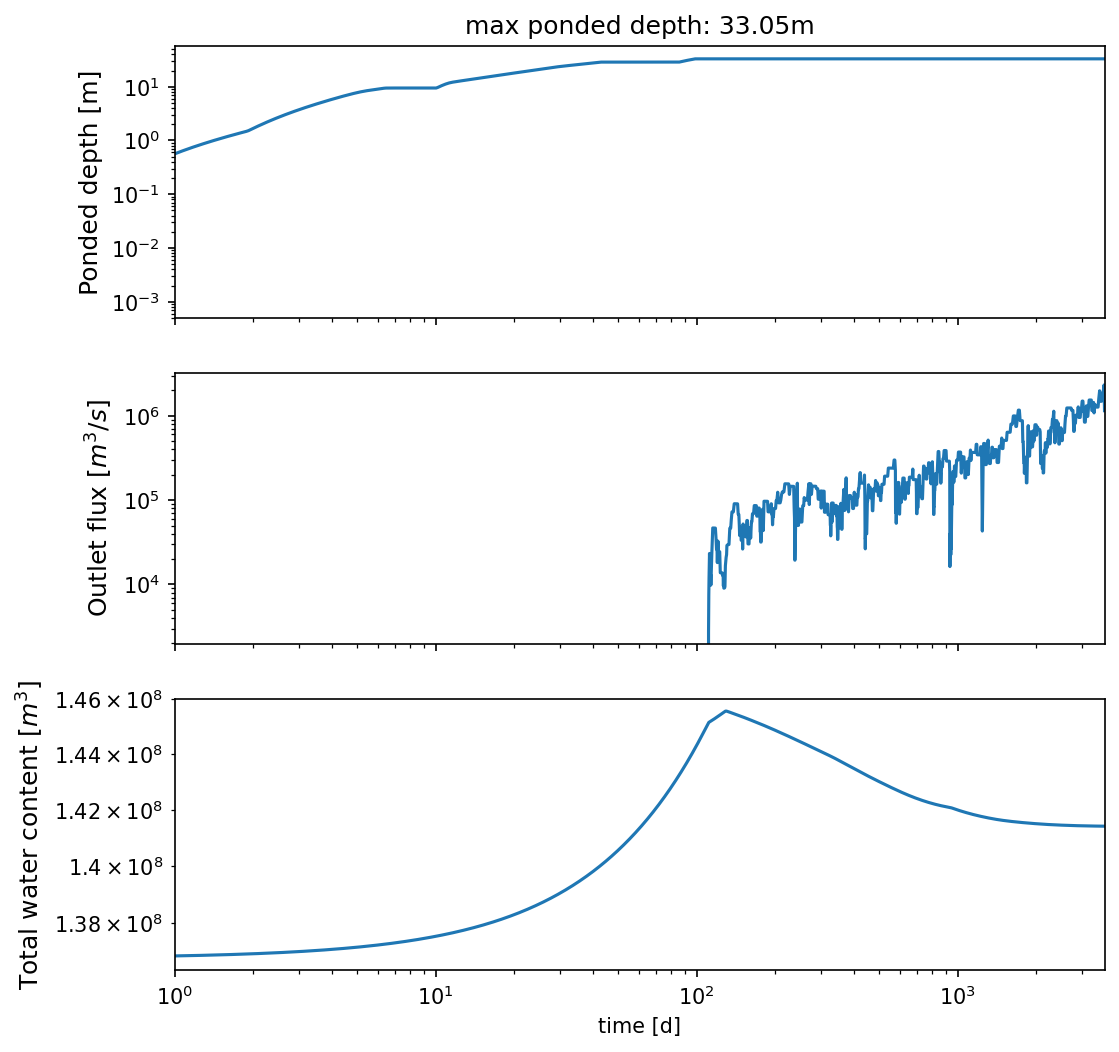

In [7]:
fig, axes = plt.subplots(3,1, figsize=(8, 8), sharex = True)
fontsize = 12
xlim = [1, df.index[-1]]

ax = axes[0]
df.plot( y='max ponded depth [m]', ax = ax)
ax.set_xlim(xlim)
ax.set_title(f"max ponded depth: {df['max ponded depth [m]'].max():.2f}m")
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Ponded depth [m]', fontsize = fontsize)
ax.get_legend().remove()
ax = axes[1]
df.plot( y='outlet flux [m^3/d]', ax = ax)
ax.set_xlim(xlim)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Outlet flux [$m^3/s$]', fontsize = fontsize)
ax.get_legend().remove()
ax = axes[2]
df.plot( y='total water content [m^3]', ax = ax)
ax.set_xlim(xlim)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Total water content [$m^3$]', fontsize = fontsize)
ax.get_legend().remove()

## plot spinup-cyclic

In [8]:
run_dir = "2-spinup_cyclic"
model_dir = os.path.join(work_dir, run_dir)
logging.info(f"Loading data from {model_dir}")

2025-04-22 20:27:54,461 - root - INFO: Loading data from ../../model2/2-spinup_cyclic


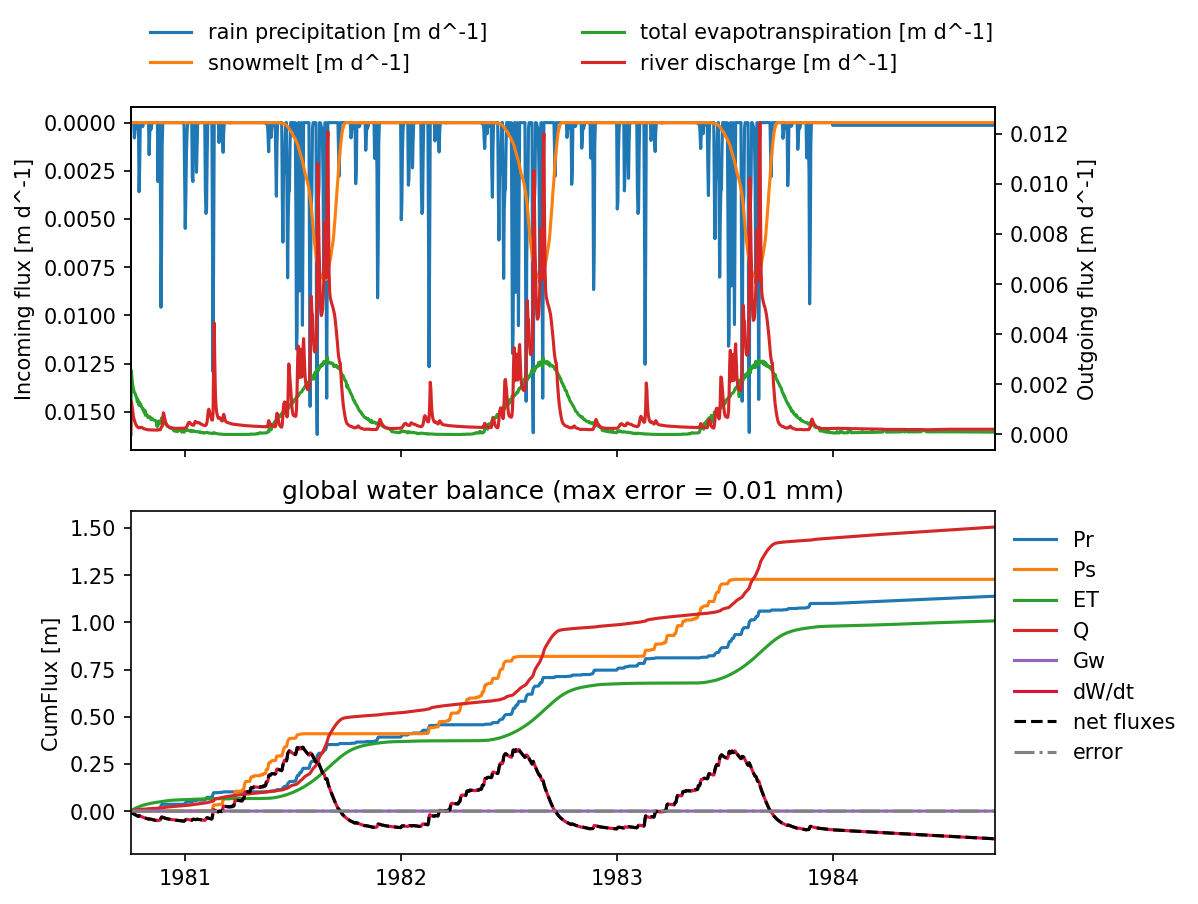

In [9]:
df = utils.load_waterBalance(model_dir, WB_filename="water_balance_computational_domain.csv",
                             domain_names = ['global'],
                                canopy = True, plot = True
                               )

## plot transient - Temp 0C 

In [10]:
run_dir = "3-transient"
model_dir = os.path.join(work_dir, run_dir)
logging.info(f"Loading data from {model_dir}")

2025-04-22 20:27:55,119 - root - INFO: Loading data from ../../model2/3-transient


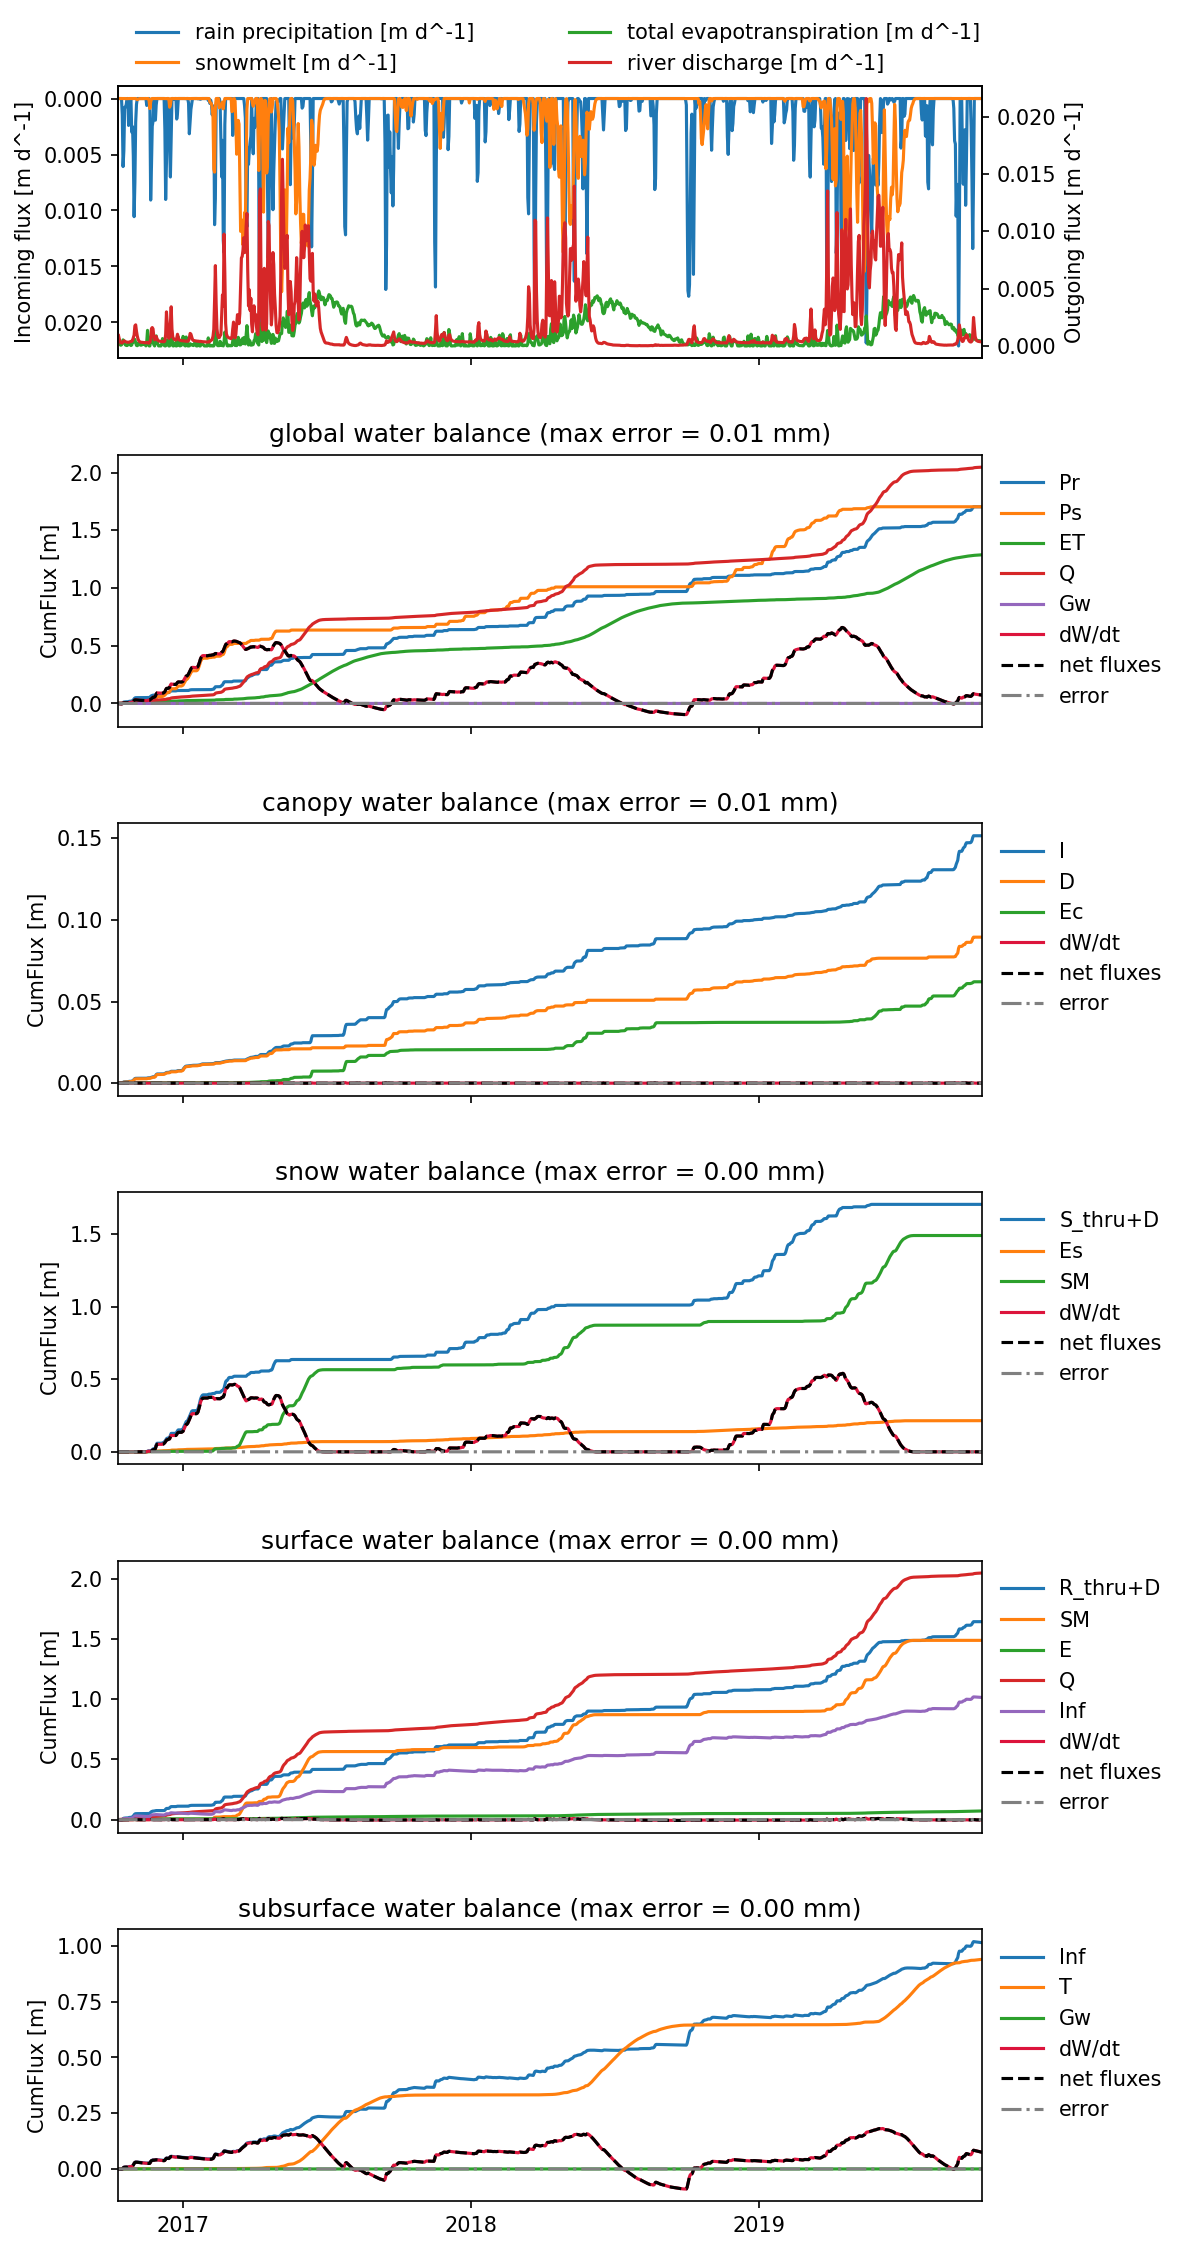

In [11]:
df = utils.load_waterBalance(model_dir, WB_filename="water_balance_computational_domain.csv",
                             domain_names = None,
                                canopy = True, plot = True
                               )

## plot transient - Temp +2

In [5]:
run_dir = "3-transient-Pos"
model_dir = os.path.join(work_dir, run_dir)
logging.info(f"Loading data from {model_dir}")

2025-04-28 00:50:51,838 - root - INFO: Loading data from ../../model2/3-transient-Pos


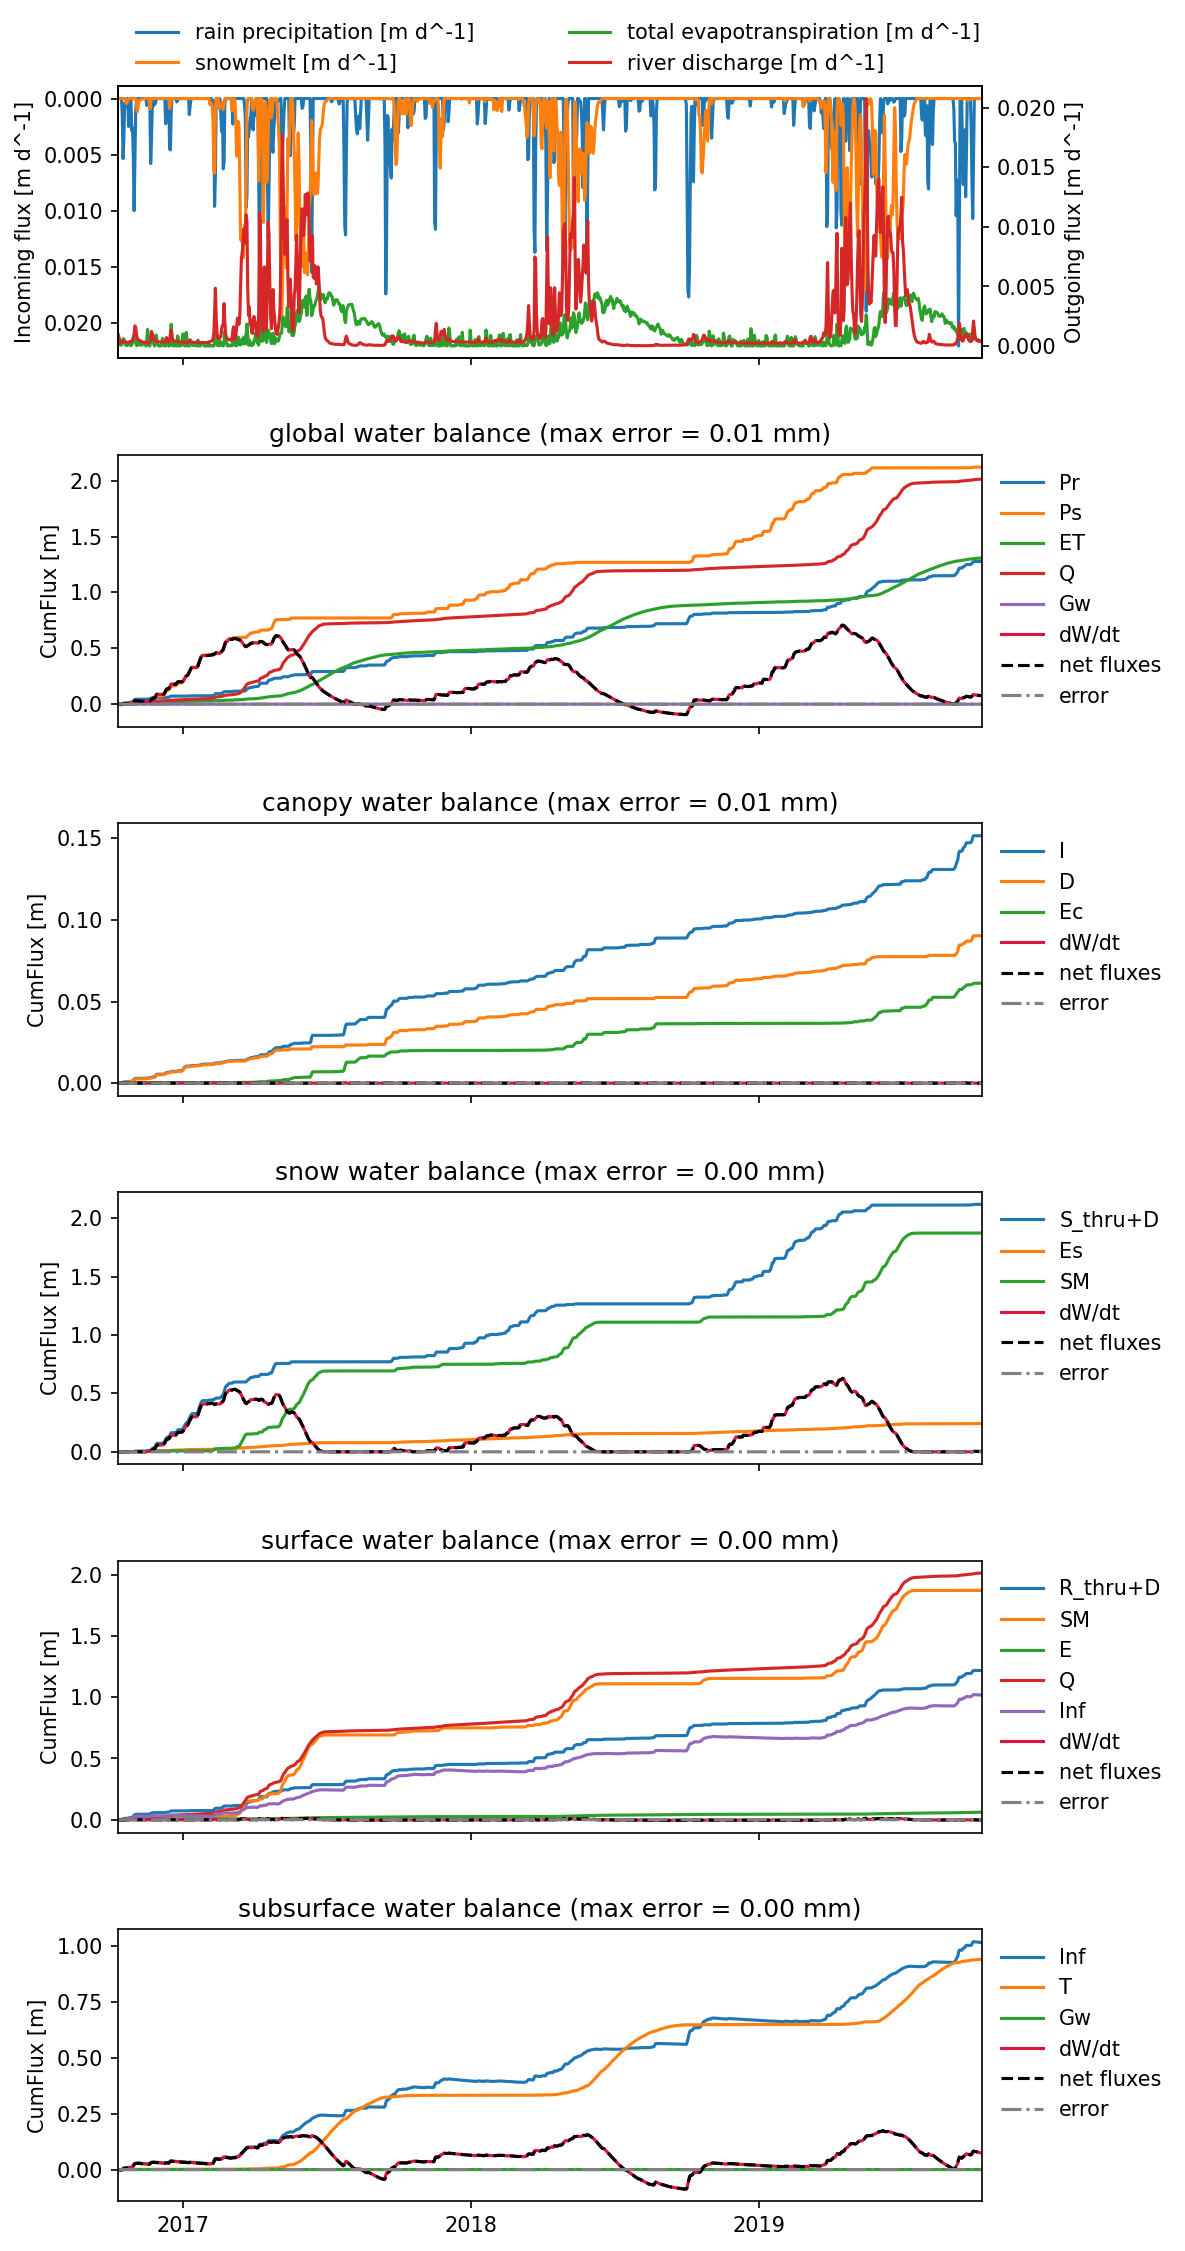

In [6]:
df = utils.load_waterBalance(model_dir, WB_filename="water_balance_computational_domain.csv",
                             domain_names = None,
                                canopy = True, plot = True
                               )

## plot transient - Temp -2

In [7]:
run_dir = "3-transient-Neg"
model_dir = os.path.join(work_dir, run_dir)
logging.info(f"Loading data from {model_dir}")

2025-04-28 00:51:28,841 - root - INFO: Loading data from ../../model2/3-transient-Neg


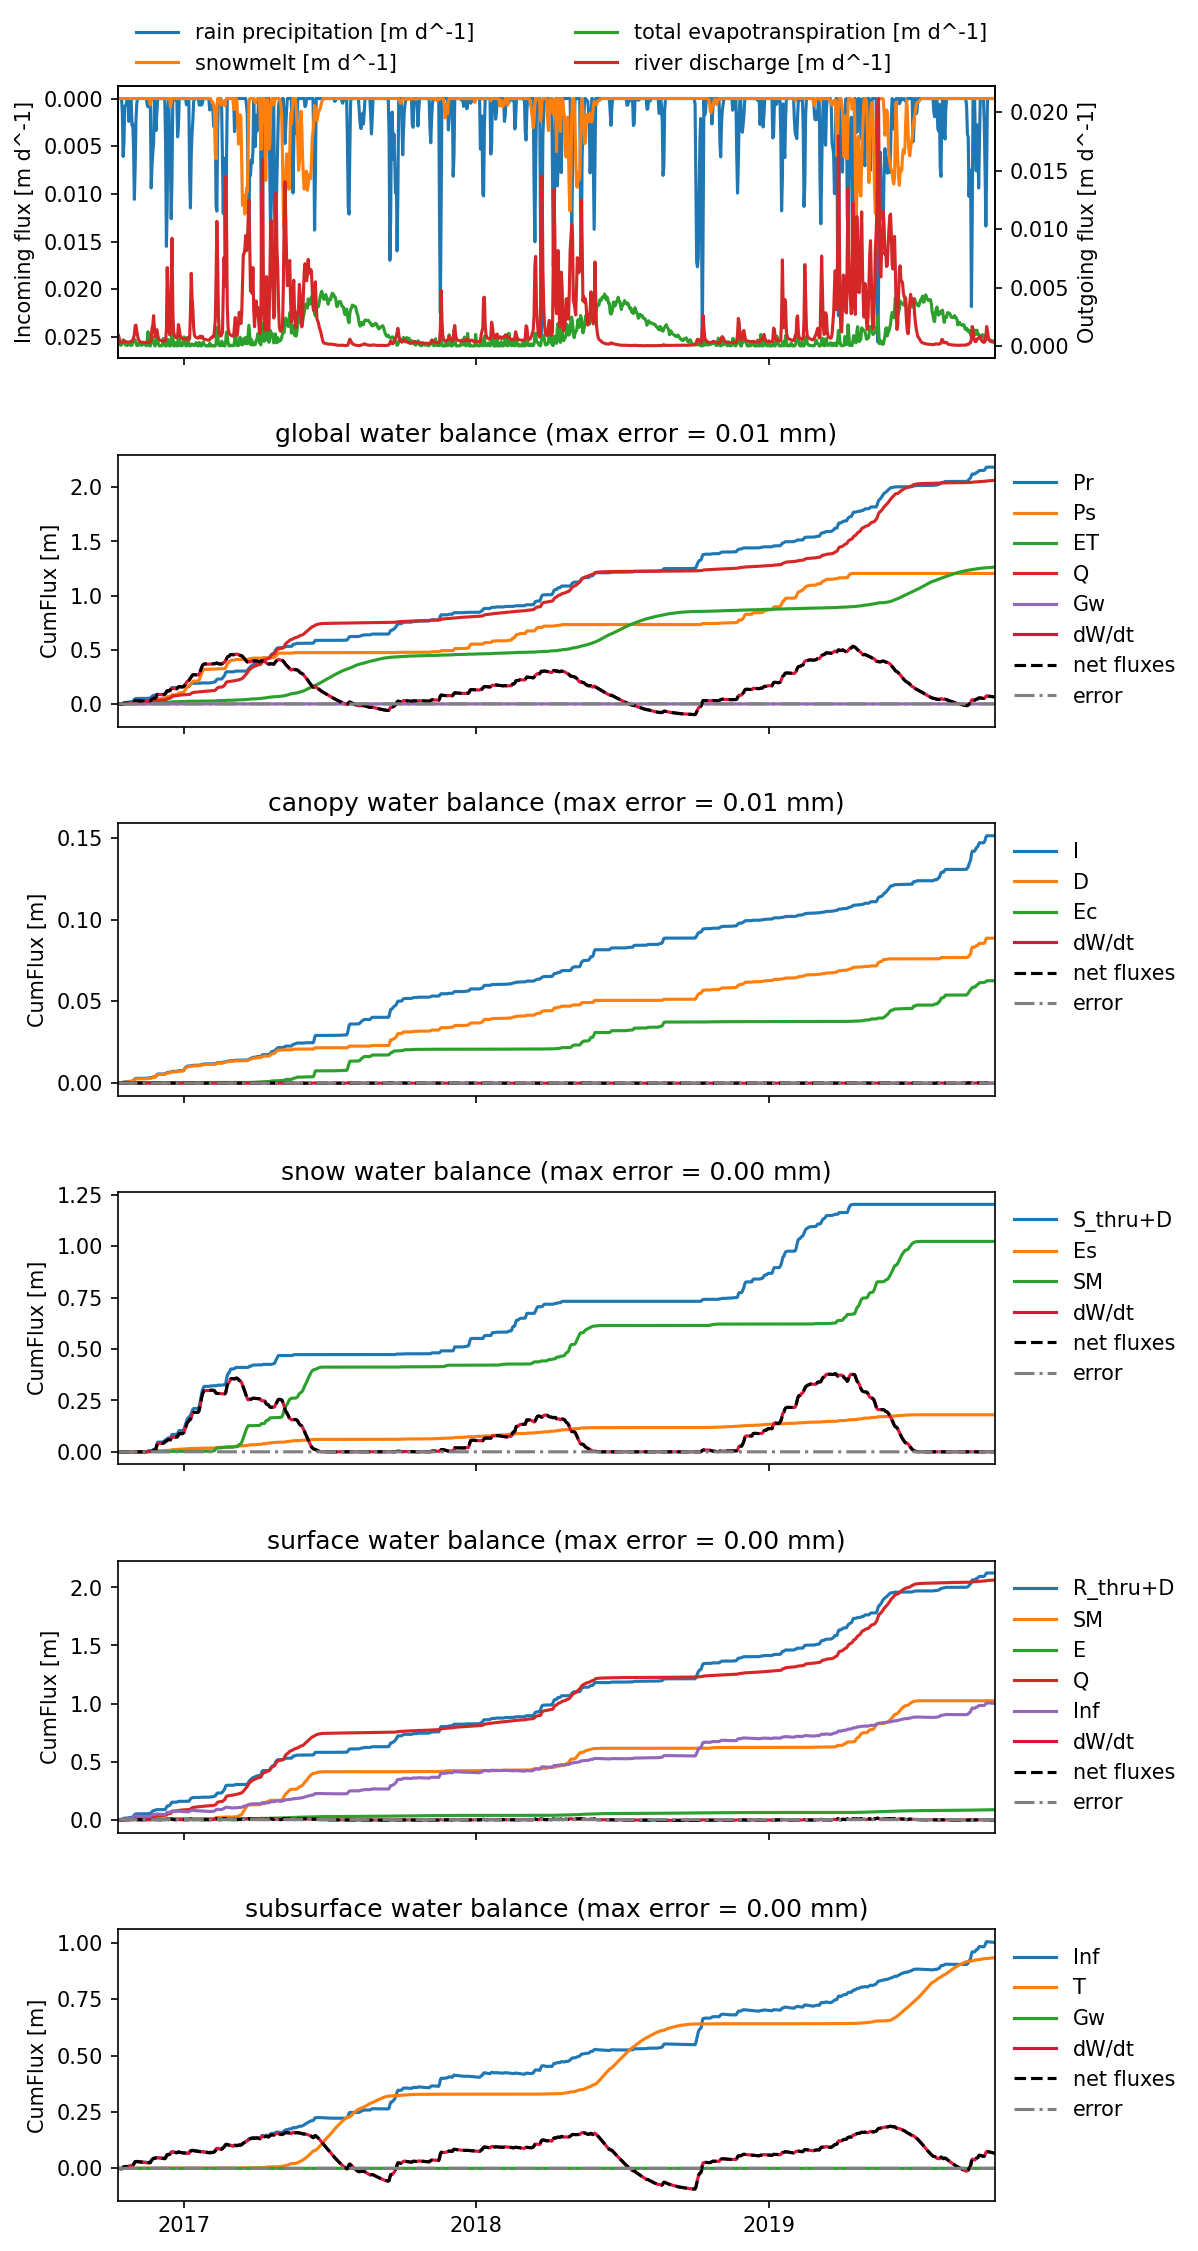

In [8]:
df = utils.load_waterBalance(model_dir, WB_filename="water_balance_computational_domain.csv",
                             domain_names = None,
                                canopy = True, plot = True
                               )

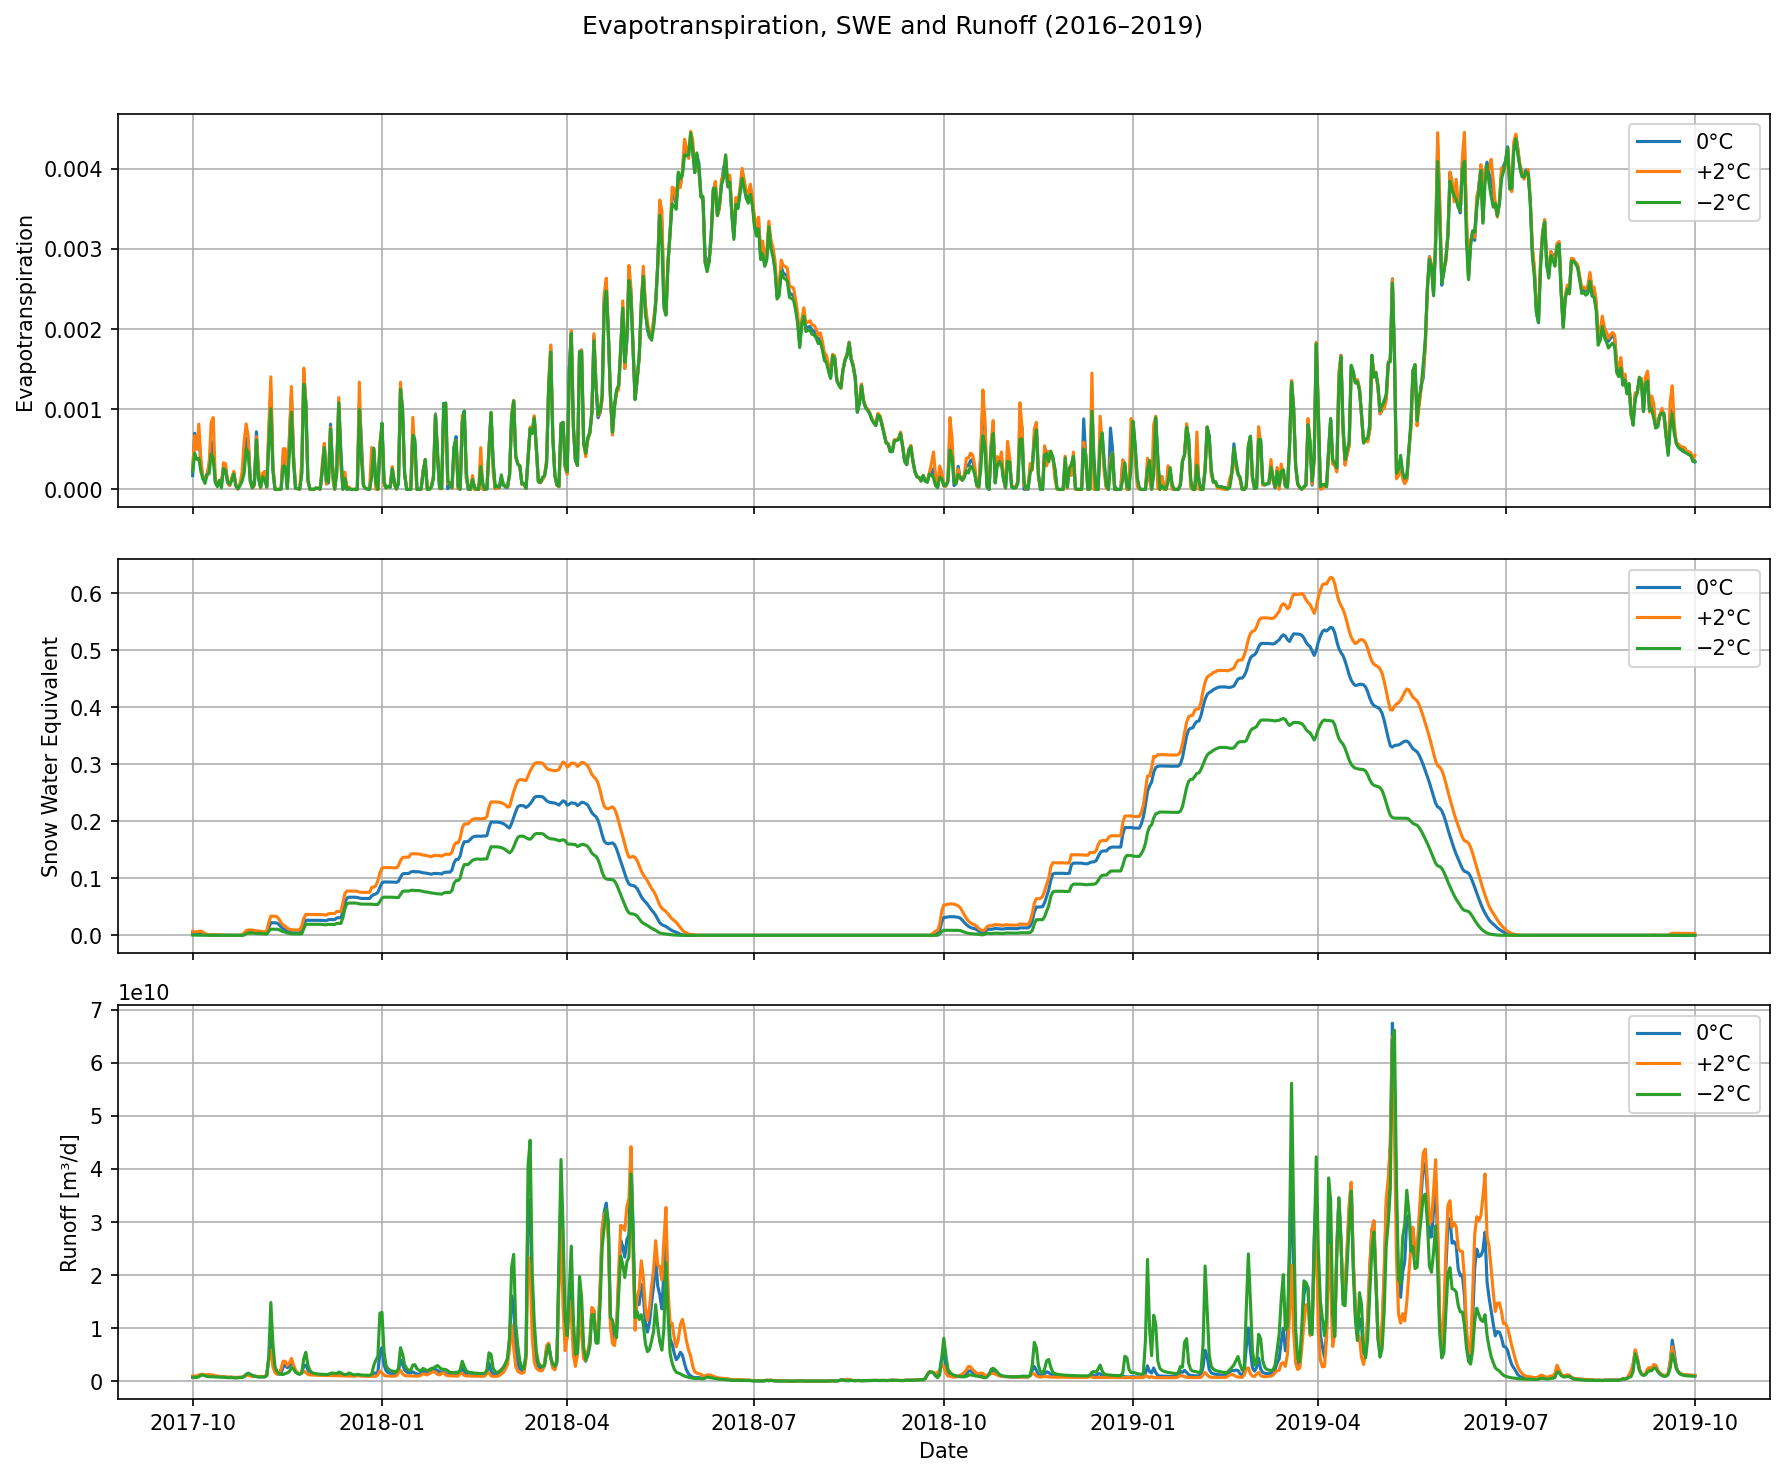

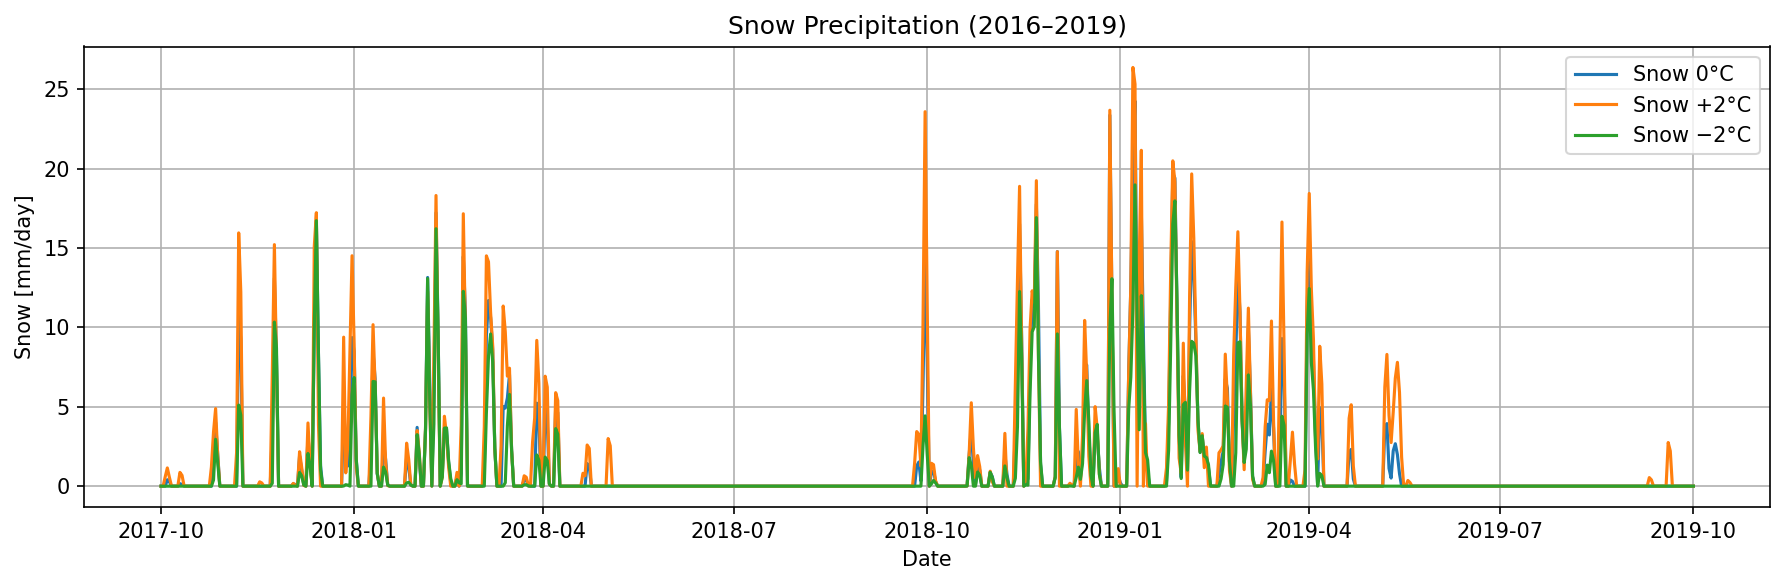

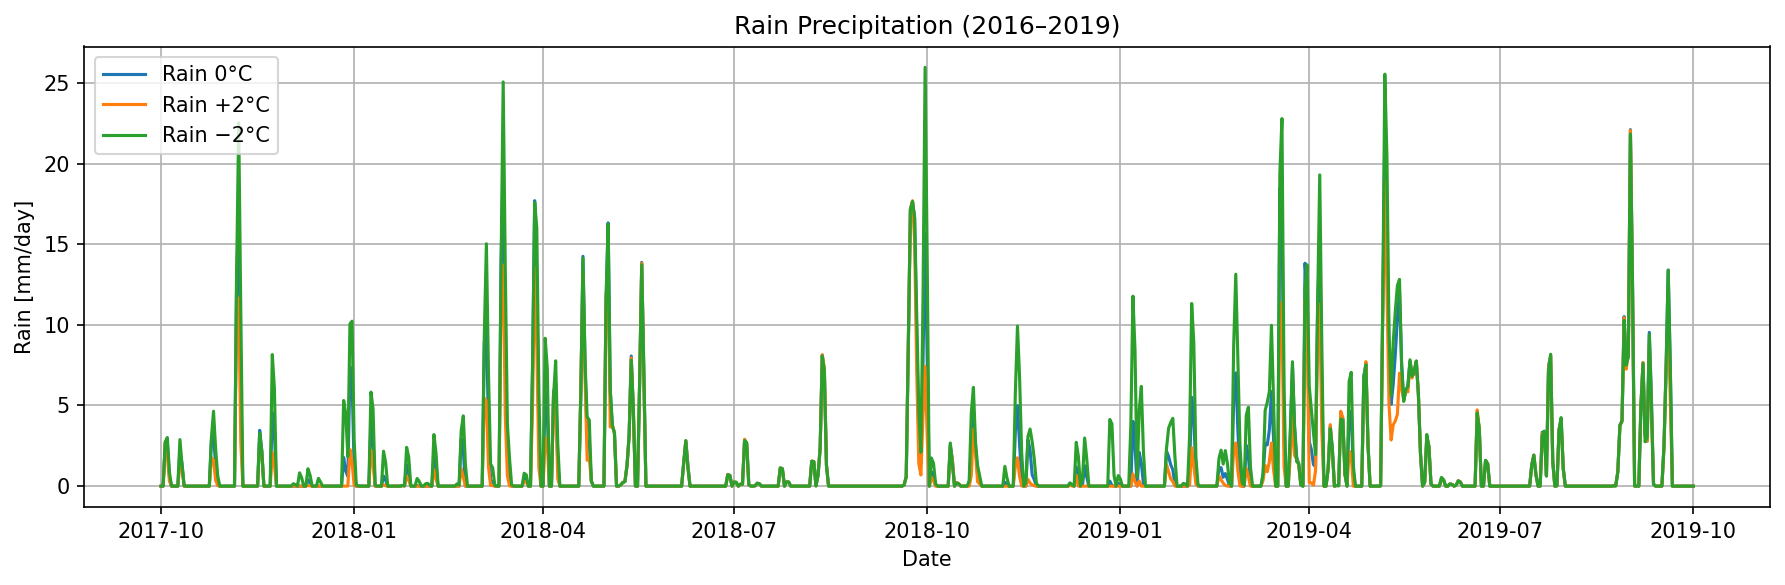


--- 2016–2017 ---
0°C: 365 registros
+2°C: 365 registros
−2°C: 365 registros


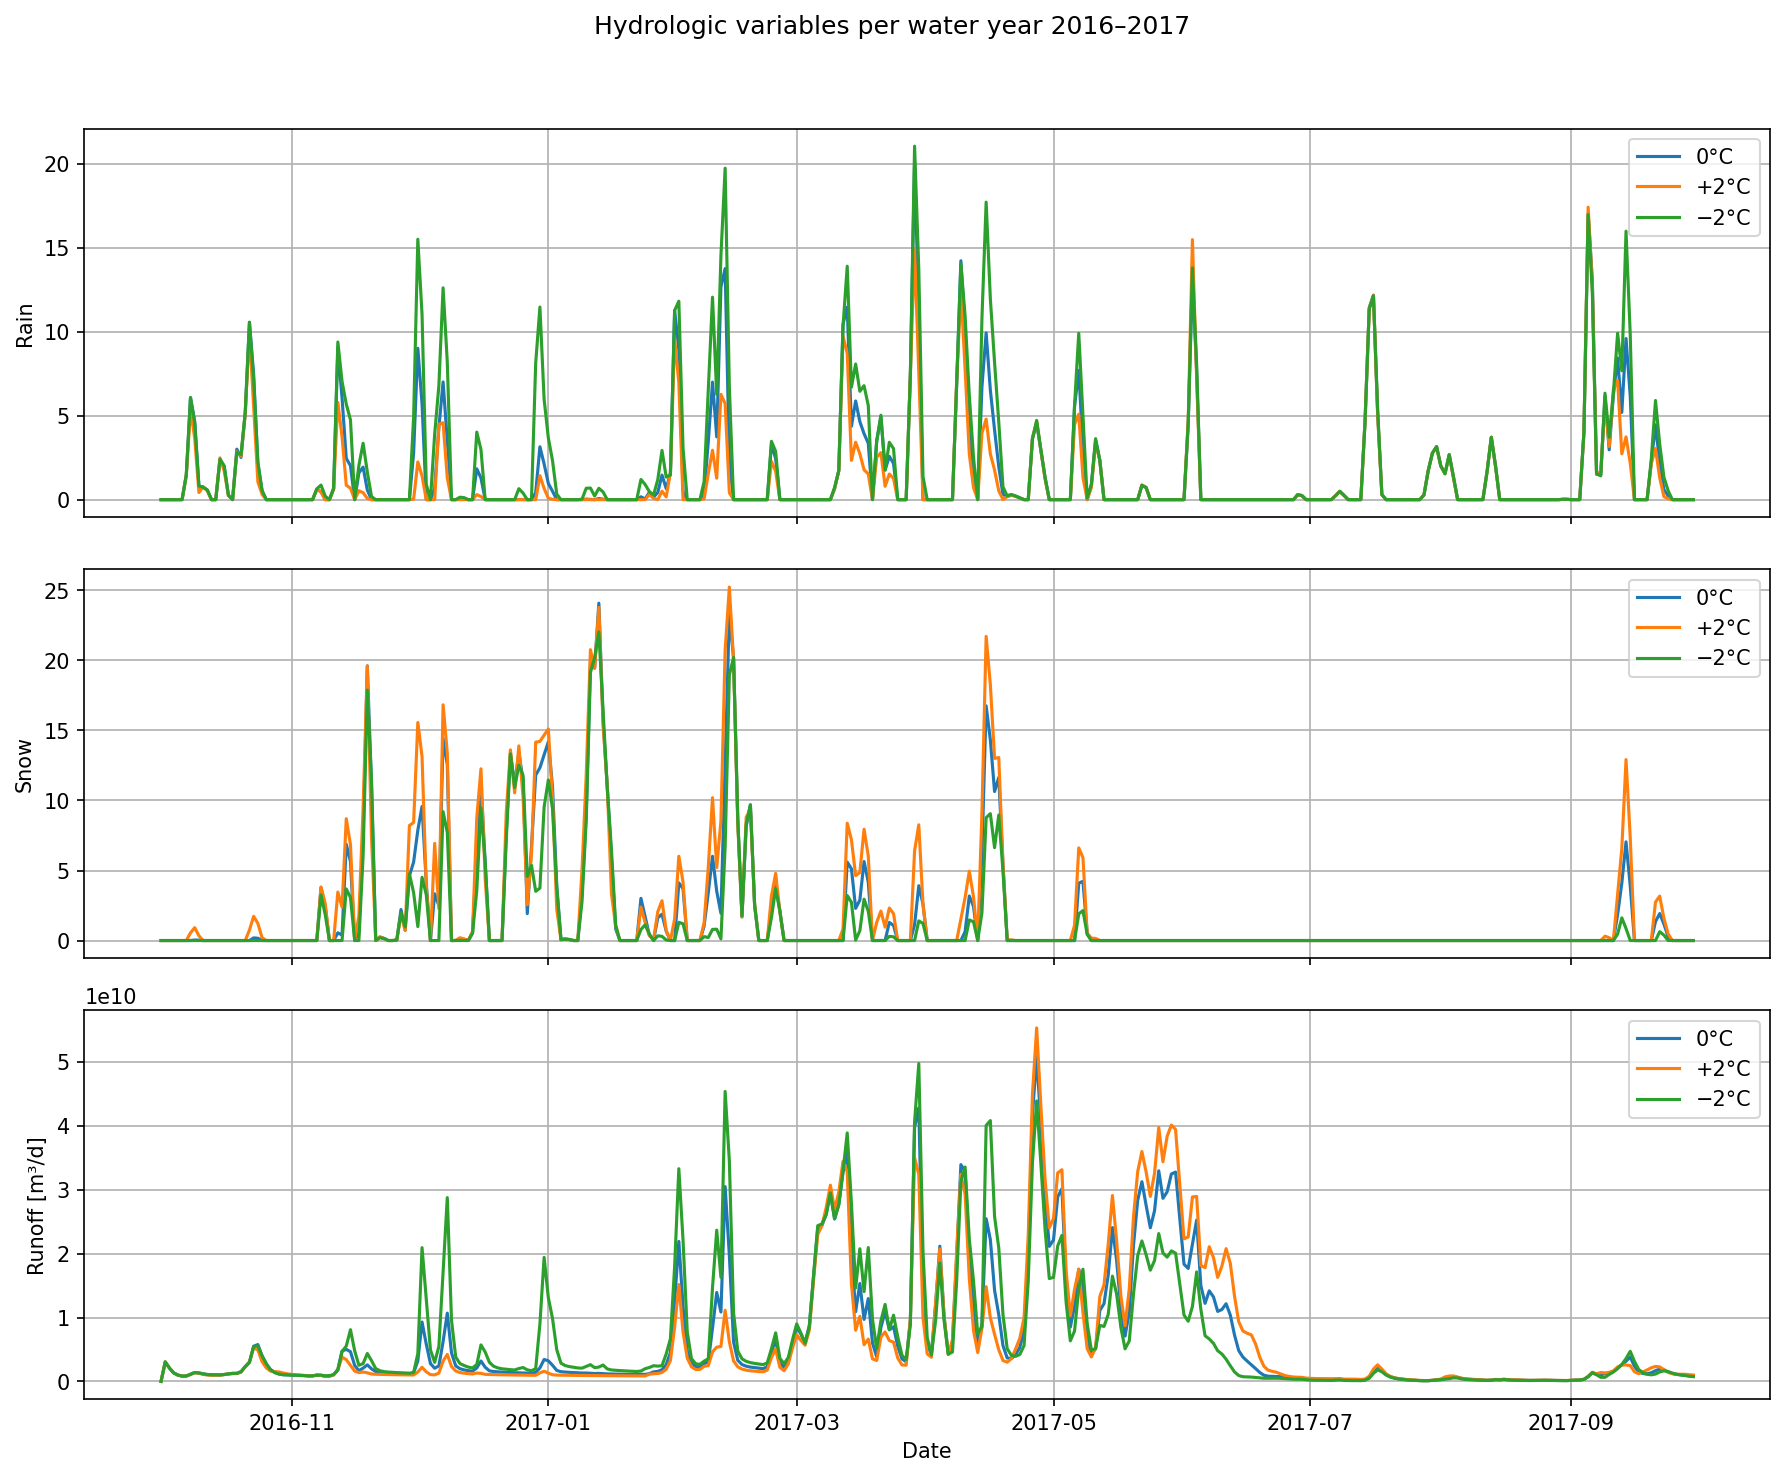


--- 2017–2018 ---
0°C: 365 registros
+2°C: 365 registros
−2°C: 365 registros


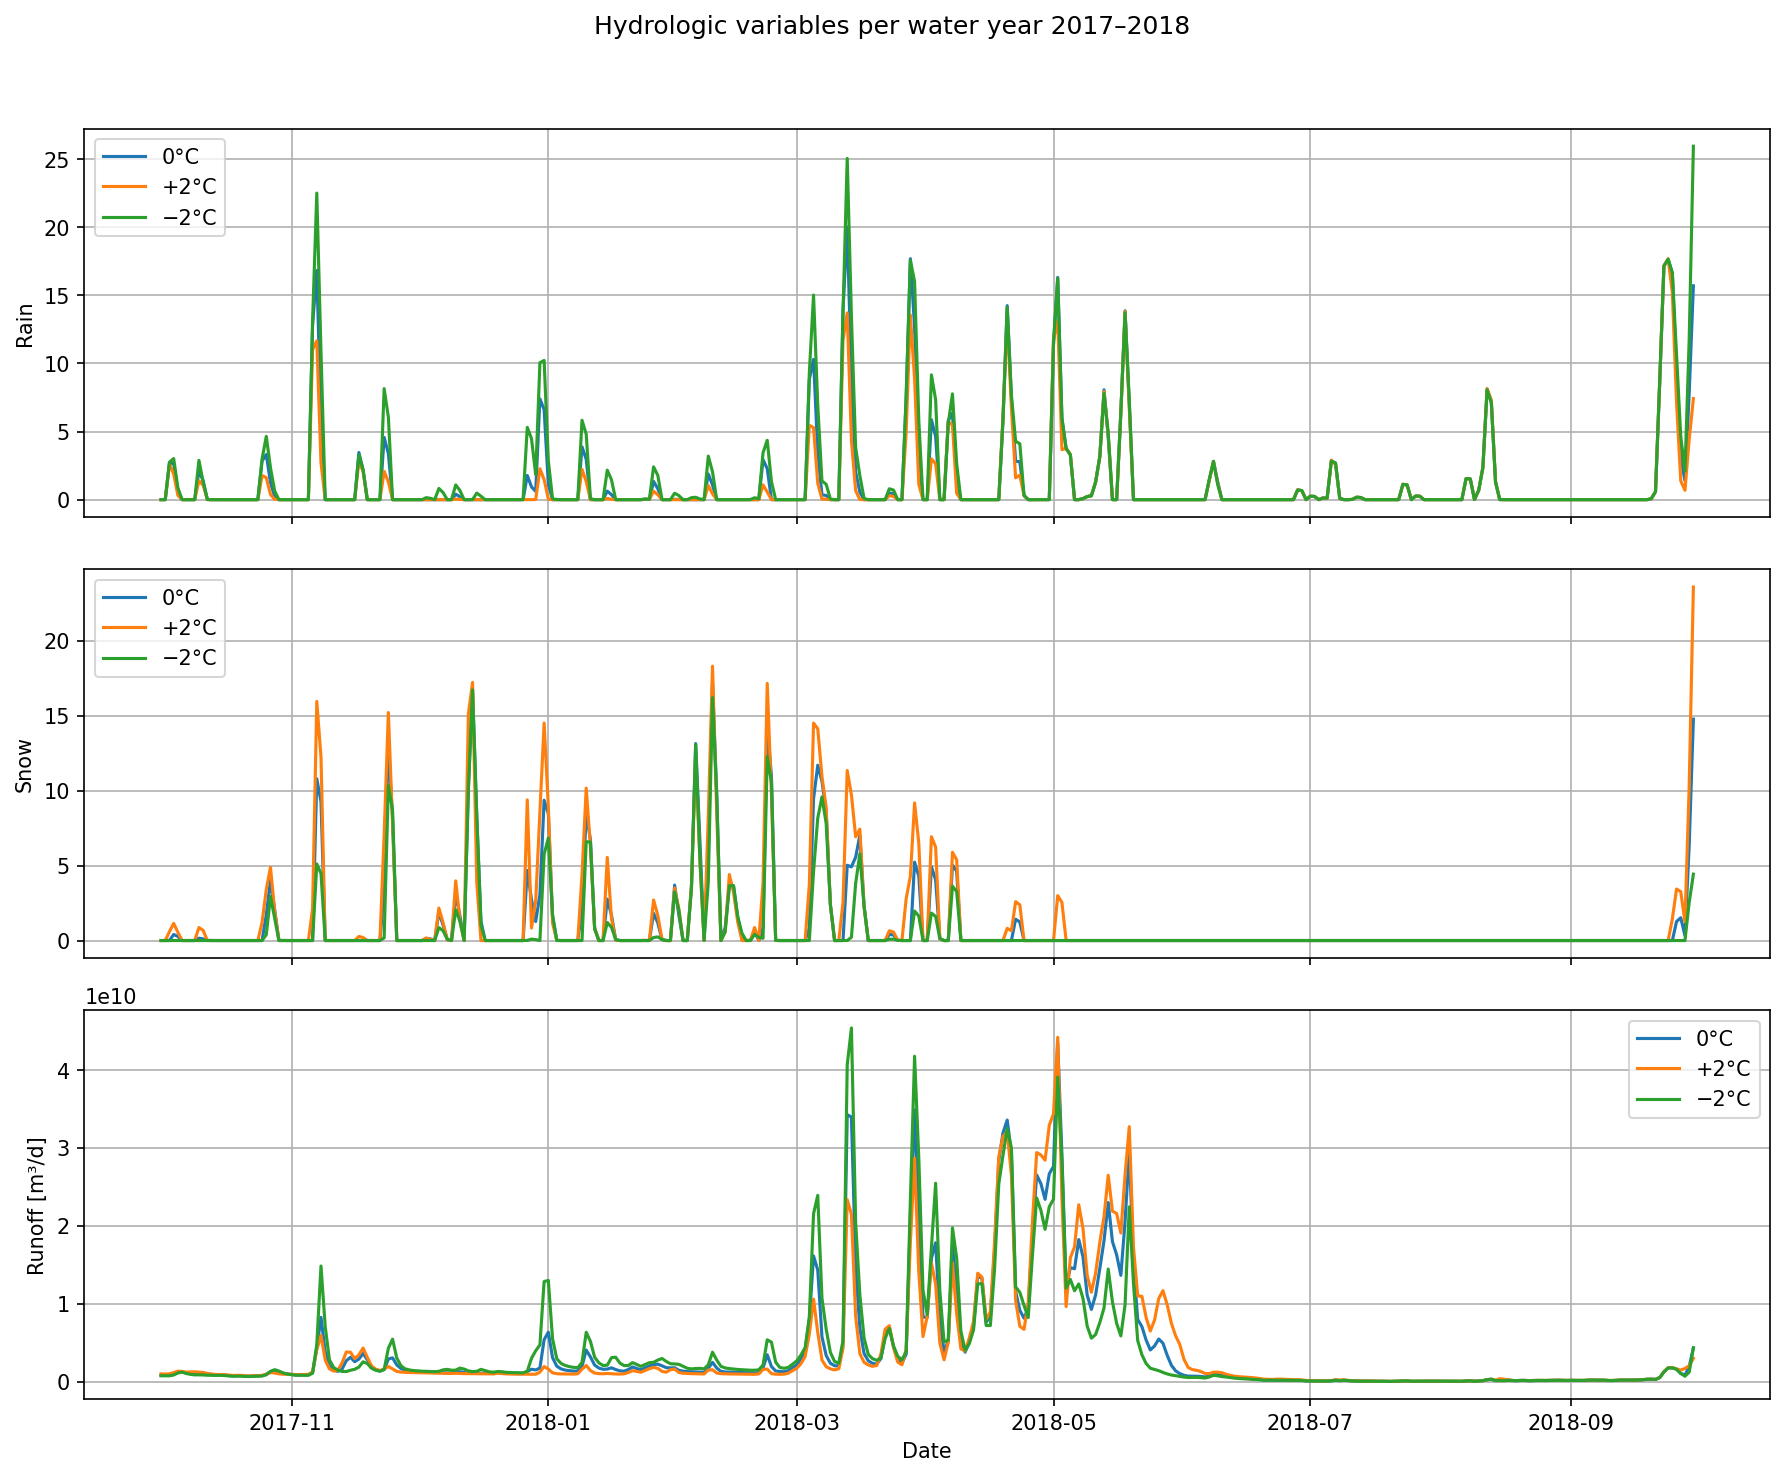


--- 2018–2019 ---
0°C: 365 registros
+2°C: 365 registros
−2°C: 365 registros


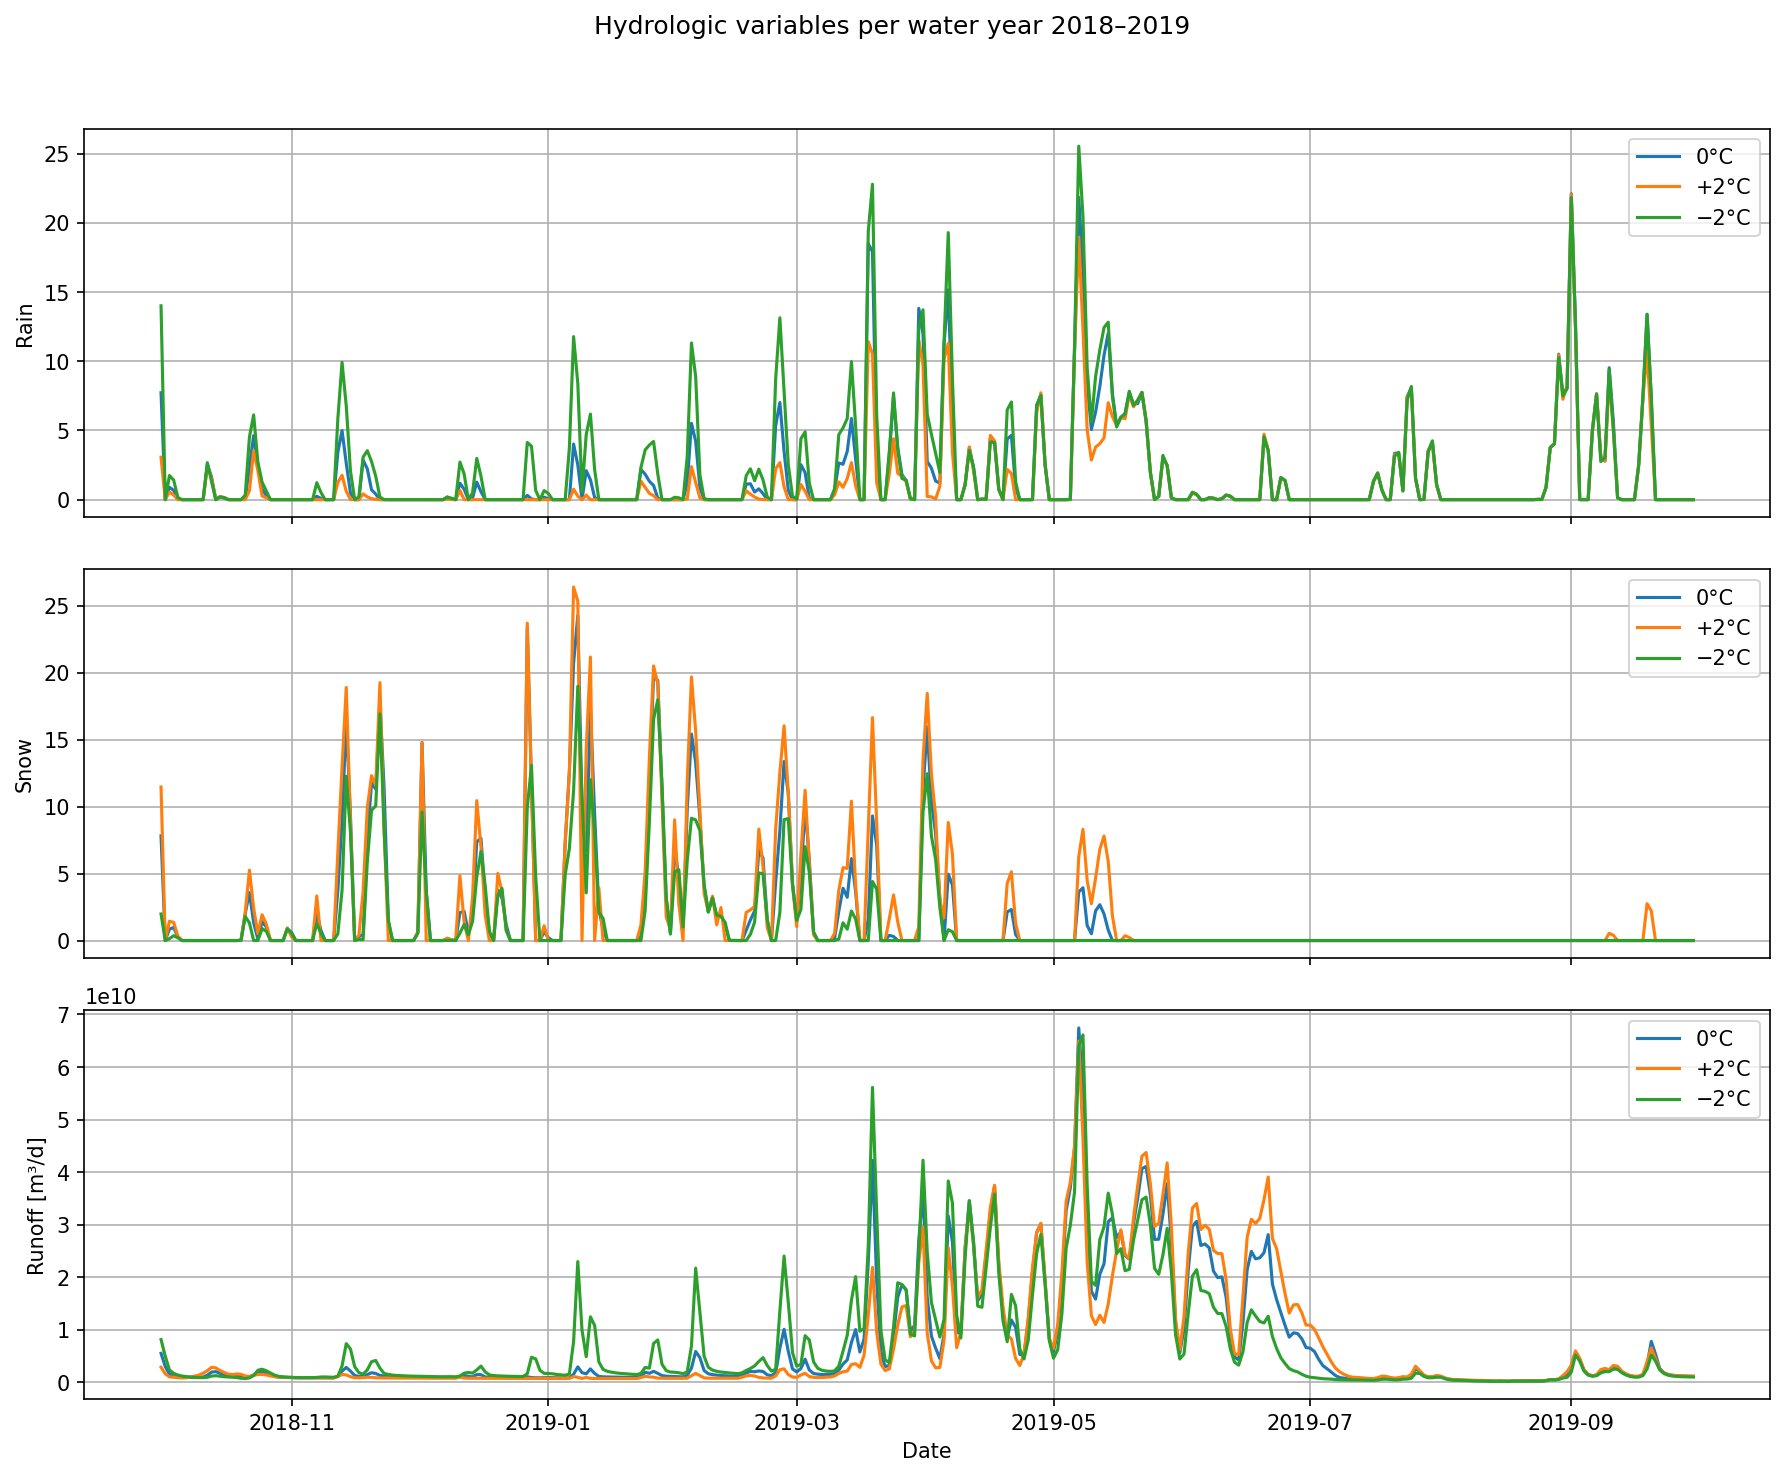

/tmp/ipykernel_1173/3987950024.py:123: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  grouped = df.resample('A').sum()
/tmp/ipykernel_1173/3987950024.py:123: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  grouped = df.resample('A').sum()
/tmp/ipykernel_1173/3987950024.py:123: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  grouped = df.resample('A').sum()
2025-04-28 18:01:01,282 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-28 18:01:01,290 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plo


--- Average snow percentage relative to total precipitation ---
0°C: 21.58%
+2°C: 24.92%
−2°C: 15.89%


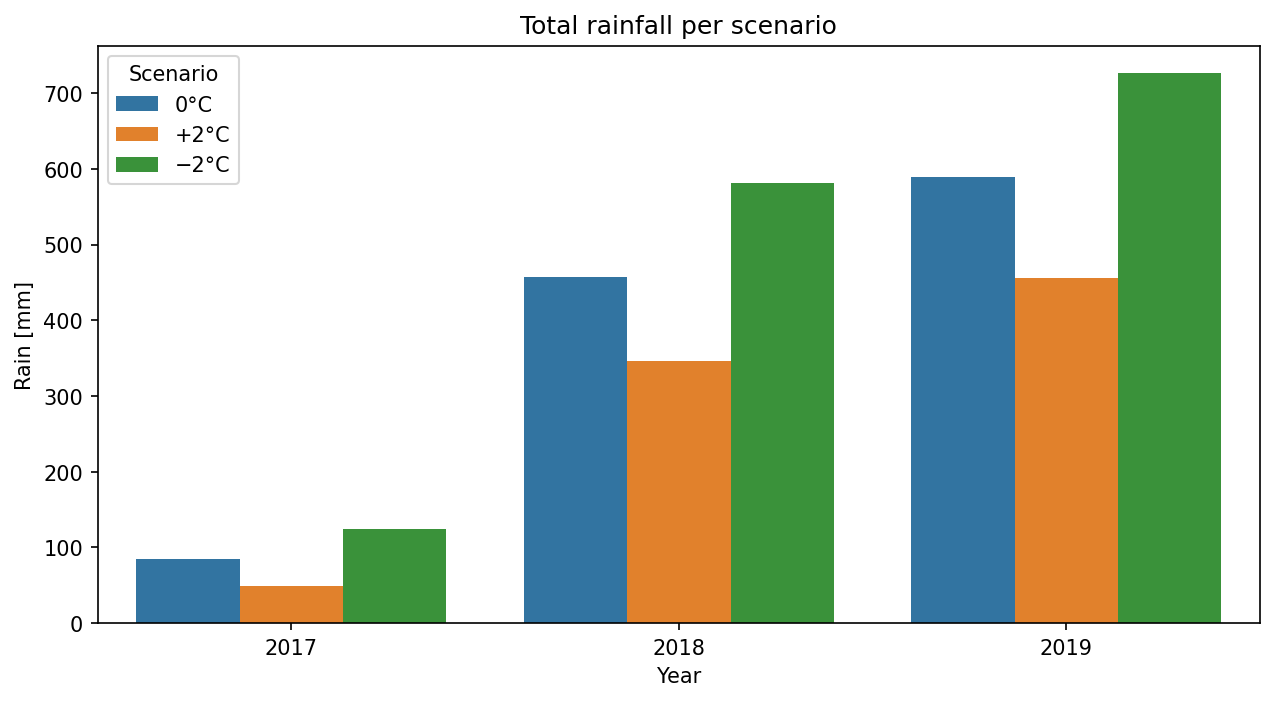

2025-04-28 18:01:01,427 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-28 18:01:01,432 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


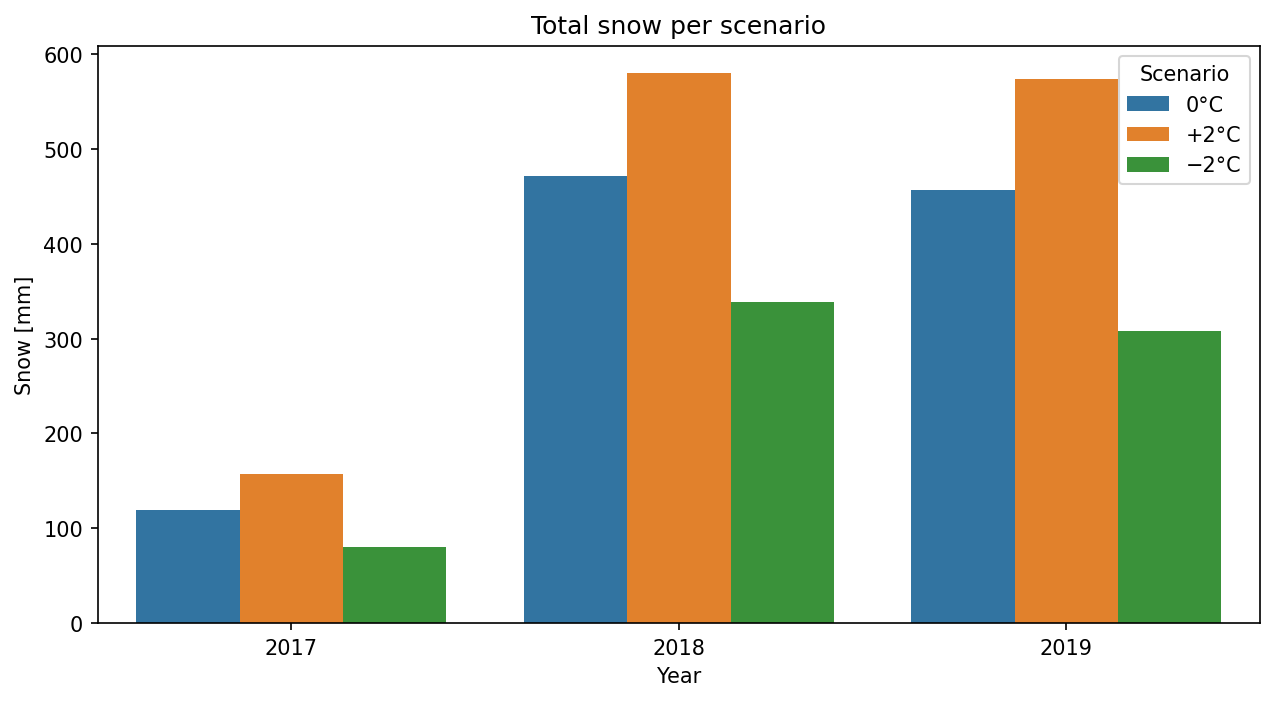

2025-04-28 18:01:01,572 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-28 18:01:01,579 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


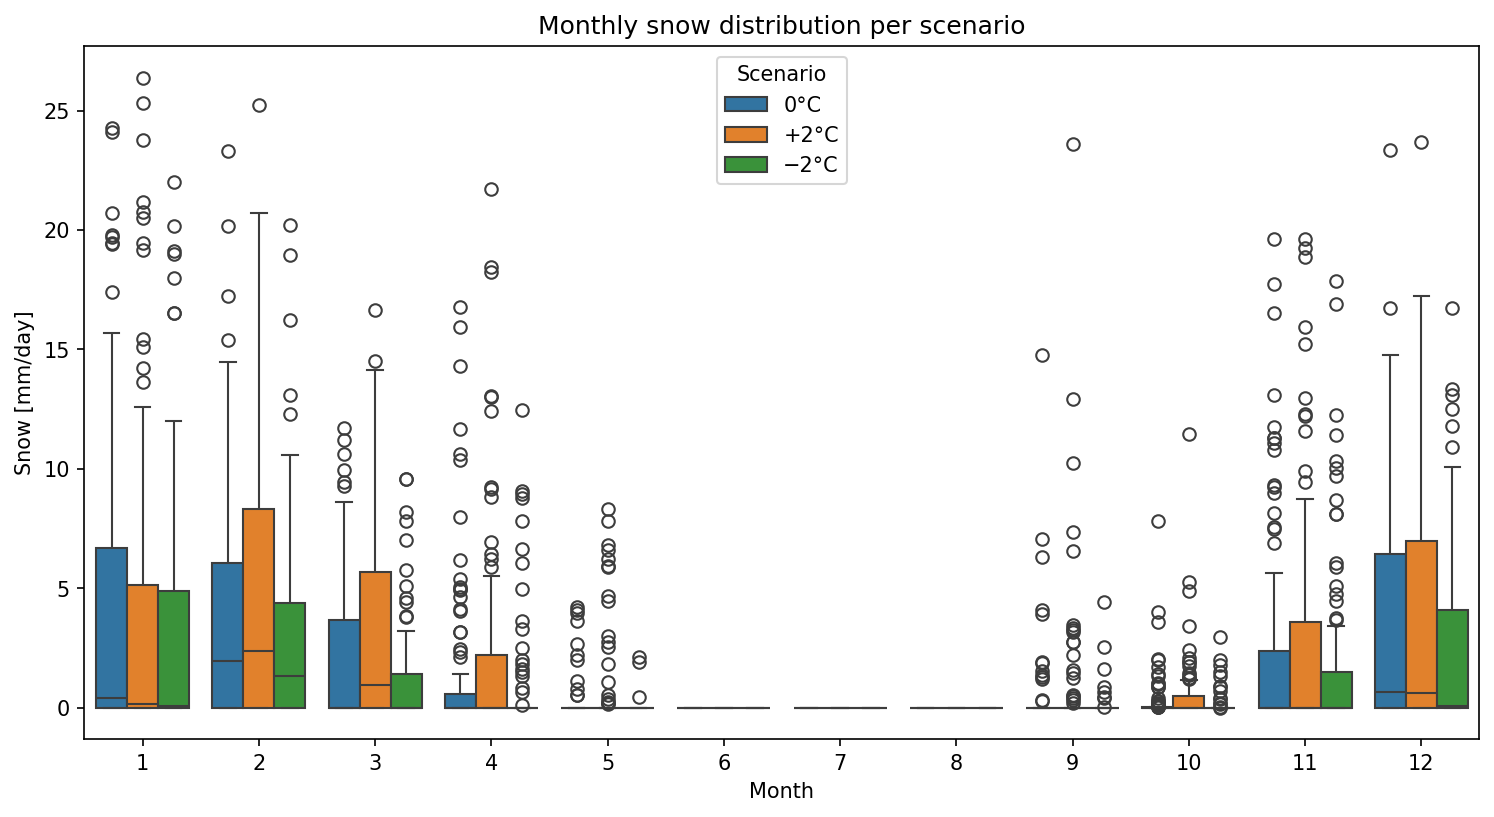

2025-04-28 18:01:02,055 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-28 18:01:02,062 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


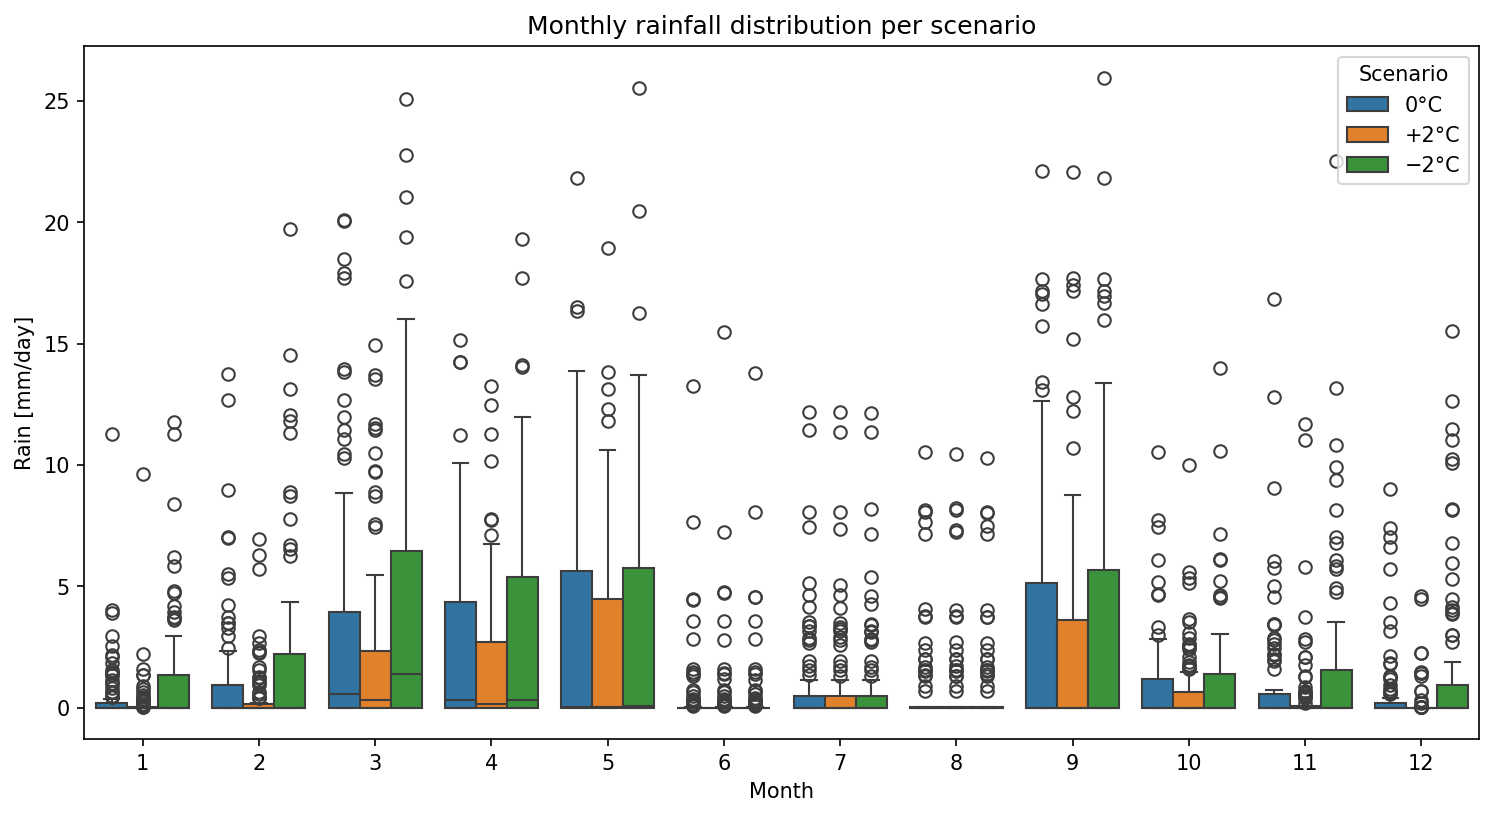


Statustical analysis per scenario (2016–2019):
Scenario              Variable         mean          std          min          max
     0°C                  Rain 1.547221e+00 3.457141e+00 0.000000e+00 2.210041e+01
     0°C                  Snow 1.432610e+00 3.556644e+00 0.000000e+00 2.426759e+01
     0°C    Evapotranspiration 1.144970e-03 1.262991e-03 0.000000e+00 4.405501e-03
     0°C Snow Water Equivalent 1.281956e-01 1.617890e-01 0.000000e+00 5.403916e-01
     0°C         Runoff [m³/d] 5.546601e+09 9.314939e+09 5.312280e+07 6.744024e+10
    +2°C                  Rain 1.163777e+00 2.860054e+00 0.000000e+00 2.205519e+01
    +2°C                  Snow 1.793902e+00 4.180992e+00 0.000000e+00 2.638729e+01
    +2°C    Evapotranspiration 1.163331e-03 1.273723e-03 0.000000e+00 4.463483e-03
    +2°C Snow Water Equivalent 1.524696e-01 1.831231e-01 0.000000e+00 6.282168e-01
    +2°C         Runoff [m³/d] 5.433887e+09 9.434052e+09 5.813094e+07 6.492242e+10
    −2°C                  Rain 1.958649

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones
work_dir = "../../model2/"  # ajusta si es necesario
scenarios = {
   "0°C": "3-transient",
    "+2°C": "3-transient-Pos",
    "−2°C": "3-transient-Neg"
}

rho_m = 55500  # mol/m³, densidad molar del agua
start_date = pd.Timestamp("2017-10-01")
end_date = pd.Timestamp("2019-12-31")

variables = {
    "rain precipitation [m d^-1]": "Rain",
    "snow precipitation [m d^-1]": "Snow",
    "total evapotranspiration [m d^-1]": "Evapotranspiration",
    "snow water equivalent [m]": "Snow Water Equivalent",
    "net runoff [mol d^-1]": "Runoff [m³/d]"
}

data_all = {}

for label, folder in scenarios.items():
    path = os.path.join(work_dir, folder, "water_balance_computational_domain.csv")
    df = pd.read_csv(path, comment="#")
    first_day = df["time [d]"].iloc[0]
    df["date"] = pd.to_datetime("2016-10-01") + pd.to_timedelta(df["time [d]"] - first_day, unit="D")
    df.set_index("date", inplace=True)

    df["Runoff [m³/d]"] = df["net runoff [mol d^-1]"] / rho_m
    df["rain precipitation [m d^-1]"] *= 1000
    df["snow precipitation [m d^-1]"] *= 1000

    df = df[[*variables.keys()]].copy()
    df.rename(columns=variables, inplace=True)
    data_all[label] = df

# === GRAFICOS GENERALES ===
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
plot_vars = ["Evapotranspiration", "Snow Water Equivalent", "Runoff [m³/d]"]

for i, var in enumerate(plot_vars):
    for label in scenarios:
        axs[i].plot(data_all[label].loc[start_date:end_date].index, data_all[label].loc[start_date:end_date][var], label=label)
    axs[i].set_ylabel(var)
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel("Date")
fig.suptitle("Evapotranspiration, SWE and Runoff (2016–2019)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.figure(figsize=(12, 4))
for label in scenarios:
    plt.plot(data_all[label].loc[start_date:end_date].index, data_all[label].loc[start_date:end_date]["Snow"], label=f"Snow {label}")
plt.title("Snow Precipitation (2016–2019)")
plt.ylabel("Snow [mm/day]")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
for label in scenarios:
    plt.plot(data_all[label].loc[start_date:end_date].index, data_all[label].loc[start_date:end_date]["Rain"], label=f"Rain {label}")
plt.title("Rain Precipitation (2016–2019)")
plt.ylabel("Rain [mm/day]")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === GRAFICOS POR AÑO HIDROLÓGICO ===
hydrological_years = [
    ("2016–2017", pd.Timestamp("2016-10-01"), pd.Timestamp("2017-09-30")),
    ("2017–2018", pd.Timestamp("2017-10-01"), pd.Timestamp("2018-09-30")),
    ("2018–2019", pd.Timestamp("2018-10-01"), pd.Timestamp("2019-09-30"))
]

for year_label, start, end in hydrological_years:
    print(f"\n--- {year_label} ---")
    for label in scenarios:
        count = len(data_all[label].loc[start:end])
        print(f"{label}: {count} registros")

    fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Hydrologic variables per water year {year_label}")

    for i, var in enumerate(["Rain", "Snow", "Runoff [m³/d]"]):
        for label in scenarios:
            subset = data_all[label].loc[start:end]
            if not subset.empty:
                axs[i].plot(subset.index, subset[var], label=label)
        axs[i].set_ylabel(var)
        axs[i].legend()
        axs[i].grid(True)

    axs[-1].set_xlabel("Date")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# === ANALISIS DE PARTICIÓN NIEVE/LLUVIA ===
# 1. Porcentaje de nieve sobre total
print("\n--- Average snow percentage relative to total precipitation ---")
for label in scenarios:
    df = data_all[label].loc[start_date:end_date]
    total_precip = df["Rain"] + df["Snow"]
    snow_fraction = (df["Snow"] / total_precip).fillna(0)
    print(f"{label}: {snow_fraction.mean() * 100:.2f}%")

# 2. Acumulado anual de lluvia y nieve por escenario
annual_totals = pd.DataFrame()
for label in scenarios:
    df = data_all[label].loc[start_date:end_date]
    grouped = df.resample('A').sum()
    grouped["Year"] = grouped.index.year
    grouped["Scenario"] = label
    annual_totals = pd.concat([annual_totals, grouped[["Rain", "Snow", "Scenario", "Year"]]])

plt.figure(figsize=(10, 5))
sns.barplot(data=annual_totals, x="Year", y="Rain", hue="Scenario")
plt.title("Total rainfall per scenario")
plt.ylabel("Rain [mm]")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=annual_totals, x="Year", y="Snow", hue="Scenario")
plt.title("Total snow per scenario")
plt.ylabel("Snow [mm]")
plt.show()

# 3. Distribución mensual con boxplot
monthly_dist = pd.DataFrame()
for label in scenarios:
    df = data_all[label].copy()
    df["Month"] = df.index.month
    df["Scenario"] = label
    monthly_dist = pd.concat([monthly_dist, df[["Rain", "Snow", "Month", "Scenario"]]])

plt.figure(figsize=(12, 6))
sns.boxplot(data=monthly_dist, x="Month", y="Snow", hue="Scenario")
plt.title("Monthly snow distribution per scenario")
plt.ylabel("Snow [mm/day]")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=monthly_dist, x="Month", y="Rain", hue="Scenario")
plt.title("Monthly rainfall distribution per scenario")
plt.ylabel("Rain [mm/day]")
plt.show()

# Análisis estadístico comparativo
stats = pd.DataFrame()
for label in scenarios:
    summary = data_all[label].loc[start_date:end_date].describe().loc[["mean", "std", "min", "max"]].T
    summary["Scenario"] = label
    stats = pd.concat([stats, summary])

stats = stats.reset_index().rename(columns={"index": "Variable"})
stats = stats[["Scenario", "Variable", "mean", "std", "min", "max"]]
print("\nStatustical analysis per scenario (2016–2019):")
print(stats.to_string(index=False))



In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones
work_dir = "../../model2/"  # ajusta si es necesario
scenarios = {
    "0°C": "3-transient",
    "+2°C": "3-transient-Pos",
    "−2°C": "3-transient-Neg"
}

rho_m = 55500  # mol/m³, densidad molar del agua
start_date = pd.Timestamp("2016-10-01")
end_date = pd.Timestamp("2019-12-31")

variables = {
    "rain precipitation [m d^-1]": "Rain",
    "snow precipitation [m d^-1]": "Snow",
    "total evapotranspiration [m d^-1]": "Evapotranspiration",
    "snow water equivalent [m]": "Snow Water Equivalent",
    "net runoff [mol d^-1]": "Runoff [m³/d]"
}

data_all = {}

for label, folder in scenarios.items():
    path = os.path.join(work_dir, folder, "water_balance_computational_domain.csv")
    df = pd.read_csv(path, comment="#")
    first_day = df["time [d]"].iloc[0]
    df["date"] = pd.to_datetime("2016-10-01") + pd.to_timedelta(df["time [d]"] - first_day, unit="D")
    df.set_index("date", inplace=True)

    df["Runoff [m³/d]"] = df["net runoff [mol d^-1]"] / rho_m
    df["rain precipitation [m d^-1]"] *= 1000
    df["snow precipitation [m d^-1]"] *= 1000

    df = df[[*variables.keys()]].copy()
    df.rename(columns=variables, inplace=True)
    data_all[label] = df

# === COMPARACIÓN ENTRE ESCENARIOS PARA TODO EL PERIODO ===
print("--- Comparación entre escenarios para todo el periodo (absoluta y relativa) ---")

base_label = "0°C"
comparison_labels = ["+2°C", "−2°C"]
comparison_summary = []

base = data_all[base_label].loc[start_date:end_date].sum()
row = {"Periodo": f"{start_date.date()} a {end_date.date()}"}
for cmp_label in comparison_labels:
    comp = data_all[cmp_label].loc[start_date:end_date].sum()
    for var in ["Rain", "Snow", "Evapotranspiration", "Snow Water Equivalent", "Runoff [m³/d]"]:
        abs_diff = comp[var] - base[var]
        rel_diff = (abs_diff / base[var]) * 100 if base[var] != 0 else 0
        row[f"{var} abs {cmp_label}"] = abs_diff
        row[f"{var} rel % {cmp_label}"] = rel_diff
comparison_summary.append(row)

comp_df = pd.DataFrame(comparison_summary)
print("{:^100}".format("COMPARACIÓN ABSOLUTA Y RELATIVA ENTRE ESCENARIOS (2016–2019)"))
print("=" * 100)
with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print(comp_df.round(2).to_string(index=False))
print("=" * 100)



--- Comparación entre escenarios para todo el periodo (absoluta y relativa) ---
                    COMPARACIÓN ABSOLUTA Y RELATIVA ENTRE ESCENARIOS (2016–2019)                    
                Periodo  Rain abs +2°C  Rain rel % +2°C  Snow abs +2°C  Snow rel % +2°C  Evapotranspiration abs +2°C  Evapotranspiration rel % +2°C  Snow Water Equivalent abs +2°C  Snow Water Equivalent rel % +2°C  Runoff [m³/d] abs +2°C  Runoff [m³/d] rel % +2°C  Rain abs −2°C  Rain rel % −2°C  Snow abs −2°C  Snow rel % −2°C  Evapotranspiration abs −2°C  Evapotranspiration rel % −2°C  Snow Water Equivalent abs −2°C  Snow Water Equivalent rel % −2°C  Runoff [m³/d] abs −2°C  Runoff [m³/d] rel % −2°C
2016-10-01 a 2019-12-31        -428.68           -25.15         415.79            24.39                         0.02                           1.51                           29.35                             19.63           -1.077762e+11                     -1.68         481.65            28.26        -500.38     

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones
work_dir = "../../model2/"  # ajusta si es necesario
scenarios = {
    "0°C": "3-transient",
    "+2°C": "3-transient-Pos",
    "−2°C": "3-transient-Neg"
}

rho_m = 55500  # mol/m³, densidad molar del agua
# NUEVO: año hidrológico 2017-2018
start_date = pd.Timestamp("2018-10-01")
end_date = pd.Timestamp("2019-09-30")

variables = {
    "rain precipitation [m d^-1]": "Rain",
    "snow precipitation [m d^-1]": "Snow",
    "total evapotranspiration [m d^-1]": "Evapotranspiration",
    "snow water equivalent [m]": "Snow Water Equivalent",
    "net runoff [mol d^-1]": "Runoff [m³/d]"
}

data_all = {}

for label, folder in scenarios.items():
    path = os.path.join(work_dir, folder, "water_balance_computational_domain.csv")
    df = pd.read_csv(path, comment="#")
    first_day = df["time [d]"].iloc[0]
    df["date"] = pd.to_datetime("2016-10-01") + pd.to_timedelta(df["time [d]"] - first_day, unit="D")
    df.set_index("date", inplace=True)

    df["Runoff [m³/d]"] = df["net runoff [mol d^-1]"] / rho_m
    df["rain precipitation [m d^-1]"] *= 1000
    df["snow precipitation [m d^-1]"] *= 1000

    df = df[[*variables.keys()]].copy()
    df.rename(columns=variables, inplace=True)
    data_all[label] = df

# === COMPARACIÓN ENTRE ESCENARIOS PARA EL AÑO HIDROLÓGICO 2017-2018 ===
print("--- Comparación entre escenarios para el año hidrológico 2017–2018 (absoluta y relativa) ---")

base_label = "0°C"
comparison_labels = ["+2°C", "−2°C"]
comparison_summary = []

base = data_all[base_label].loc[start_date:end_date].sum()
row = {"Periodo": f"{start_date.date()} a {end_date.date()}"}
for cmp_label in comparison_labels:
    comp = data_all[cmp_label].loc[start_date:end_date].sum()
    for var in ["Rain", "Snow", "Evapotranspiration", "Snow Water Equivalent", "Runoff [m³/d]"]:
        abs_diff = comp[var] - base[var]
        rel_diff = (abs_diff / base[var]) * 100 if base[var] != 0 else 0
        row[f"{var} abs {cmp_label}"] = abs_diff
        row[f"{var} rel % {cmp_label}"] = rel_diff
comparison_summary.append(row)

comp_df = pd.DataFrame(comparison_summary)
print("{:^100}".format("COMPARACIÓN ABSOLUTA Y RELATIVA ENTRE ESCENARIOS (2017–2018)"))
print("=" * 100)
with pd.option_context('display.max_columns', None, 'display.expand_frame_repr', False):
    print(comp_df.round(2).to_string(index=False))
print("=" * 100)

--- Comparación entre escenarios para el año hidrológico 2017–2018 (absoluta y relativa) ---
                    COMPARACIÓN ABSOLUTA Y RELATIVA ENTRE ESCENARIOS (2017–2018)                    
                Periodo  Rain abs +2°C  Rain rel % +2°C  Snow abs +2°C  Snow rel % +2°C  Evapotranspiration abs +2°C  Evapotranspiration rel % +2°C  Snow Water Equivalent abs +2°C  Snow Water Equivalent rel % +2°C  Runoff [m³/d] abs +2°C  Runoff [m³/d] rel % +2°C  Rain abs −2°C  Rain rel % −2°C  Snow abs −2°C  Snow rel % −2°C  Evapotranspiration abs −2°C  Evapotranspiration rel % −2°C  Snow Water Equivalent abs −2°C  Snow Water Equivalent rel % −2°C  Runoff [m³/d] abs −2°C  Runoff [m³/d] rel % −2°C
2018-10-01 a 2019-09-30        -160.74           -25.25         139.86             20.9                         0.01                           1.25                           10.79                              15.4           -7.506333e+10                     -2.88         184.16            28.92       

--- Análisis automático para el año hidrológico 2018–2019 ---


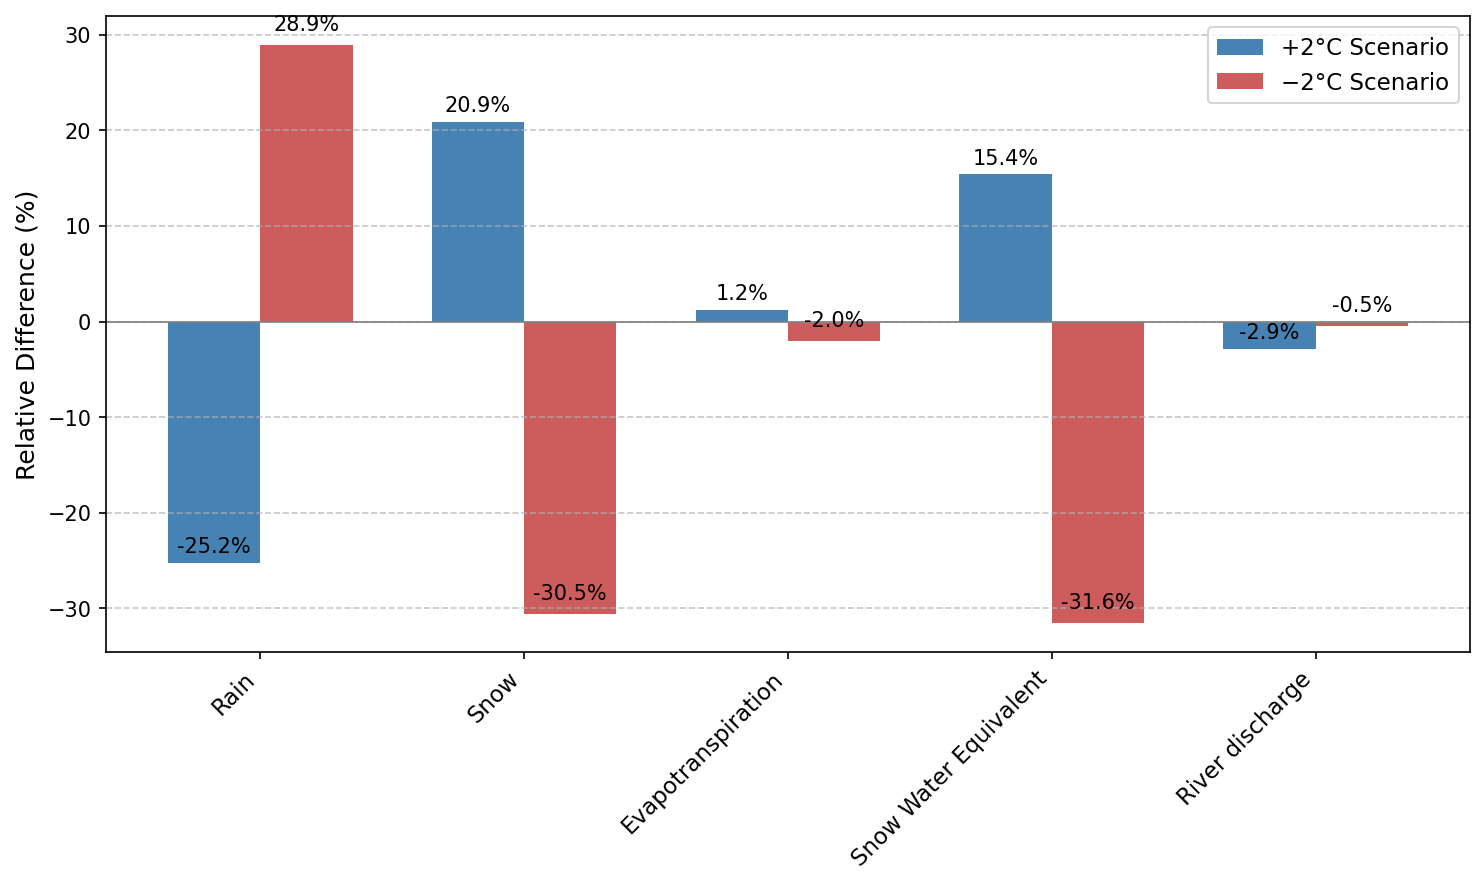

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Configuraciones principales
work_dir = "../../model2/"
scenarios = {
    "0°C": "3-transient",
    "+2°C": "3-transient-Pos",
    "−2°C": "3-transient-Neg"
}

rho_m = 55500  # mol/m³
start_date = pd.Timestamp("2018-10-01")
end_date = pd.Timestamp("2019-09-30")

variables = {
    "rain precipitation [m d^-1]": "Rain",
    "snow precipitation [m d^-1]": "Snow",
    "total evapotranspiration [m d^-1]": "Evapotranspiration",
    "snow water equivalent [m]": "Snow Water Equivalent",
    "net runoff [mol d^-1]": "River discharge"
}

# Leer y procesar los datos
data_all = {}
for label, folder in scenarios.items():
    path = os.path.join(work_dir, folder, "water_balance_computational_domain.csv")
    df = pd.read_csv(path, comment="#")
    first_day = df["time [d]"].iloc[0]
    df["date"] = pd.to_datetime("2016-10-01") + pd.to_timedelta(df["time [d]"] - first_day, unit="D")
    df.set_index("date", inplace=True)

    df["River discharge"] = df["net runoff [mol d^-1]"] / rho_m
    df["rain precipitation [m d^-1]"] *= 1000
    df["snow precipitation [m d^-1]"] *= 1000

    df = df[[*variables.keys()]].copy()
    df.rename(columns=variables, inplace=True)
    data_all[label] = df

# Análisis comparativo automático
print("--- Análisis automático para el año hidrológico 2018–2019 ---")

base_label = "0°C"
comparison_labels = ["+2°C", "−2°C"]
comparison_summary = []

base = data_all[base_label].loc[start_date:end_date].sum()
row = {"Periodo": f"{start_date.date()} a {end_date.date()}"}
for cmp_label in comparison_labels:
    comp = data_all[cmp_label].loc[start_date:end_date].sum()
    for var in ["Rain", "Snow", "Evapotranspiration", "Snow Water Equivalent", "River discharge"]:
        abs_diff = comp[var] - base[var]
        rel_diff = (abs_diff / base[var]) * 100 if base[var] != 0 else 0
        row[f"{var} abs {cmp_label}"] = abs_diff
        row[f"{var} rel % {cmp_label}"] = rel_diff
comparison_summary.append(row)

comp_df = pd.DataFrame(comparison_summary)

# === Gráfico automático de diferencias relativas ===
# Preparar los datos de diferencias relativas
variables_plot = ["Rain", "Snow", "Evapotranspiration", "Snow Water Equivalent", "River discharge"]
rel_diff_data = {
    "Variable": variables_plot,
    "+2°C": [comp_df[f"{var} rel % +2°C"].iloc[0] for var in variables_plot],
    "−2°C": [comp_df[f"{var} rel % −2°C"].iloc[0] for var in variables_plot]
}

rel_diff_df = pd.DataFrame(rel_diff_data)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
x = range(len(rel_diff_df))

bars_pos = ax.bar([i - bar_width/2 for i in x], rel_diff_df["+2°C"], width=bar_width, label="+2°C Scenario", color='steelblue')
bars_neg = ax.bar([i + bar_width/2 for i in x], rel_diff_df["−2°C"], width=bar_width, label="−2°C Scenario", color='indianred')

ax.set_ylabel('Relative Difference (%)', fontsize=12)
#ax.set_title('Relative Differences Compared to Baseline (0°C)\nHydrological Year 2017–2018', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(rel_diff_df["Variable"], rotation=45, ha='right', fontsize=11)
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas numéricas encima de cada barra
for bar in bars_pos:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # distancia de separación
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for bar in bars_neg:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()

plt.show()

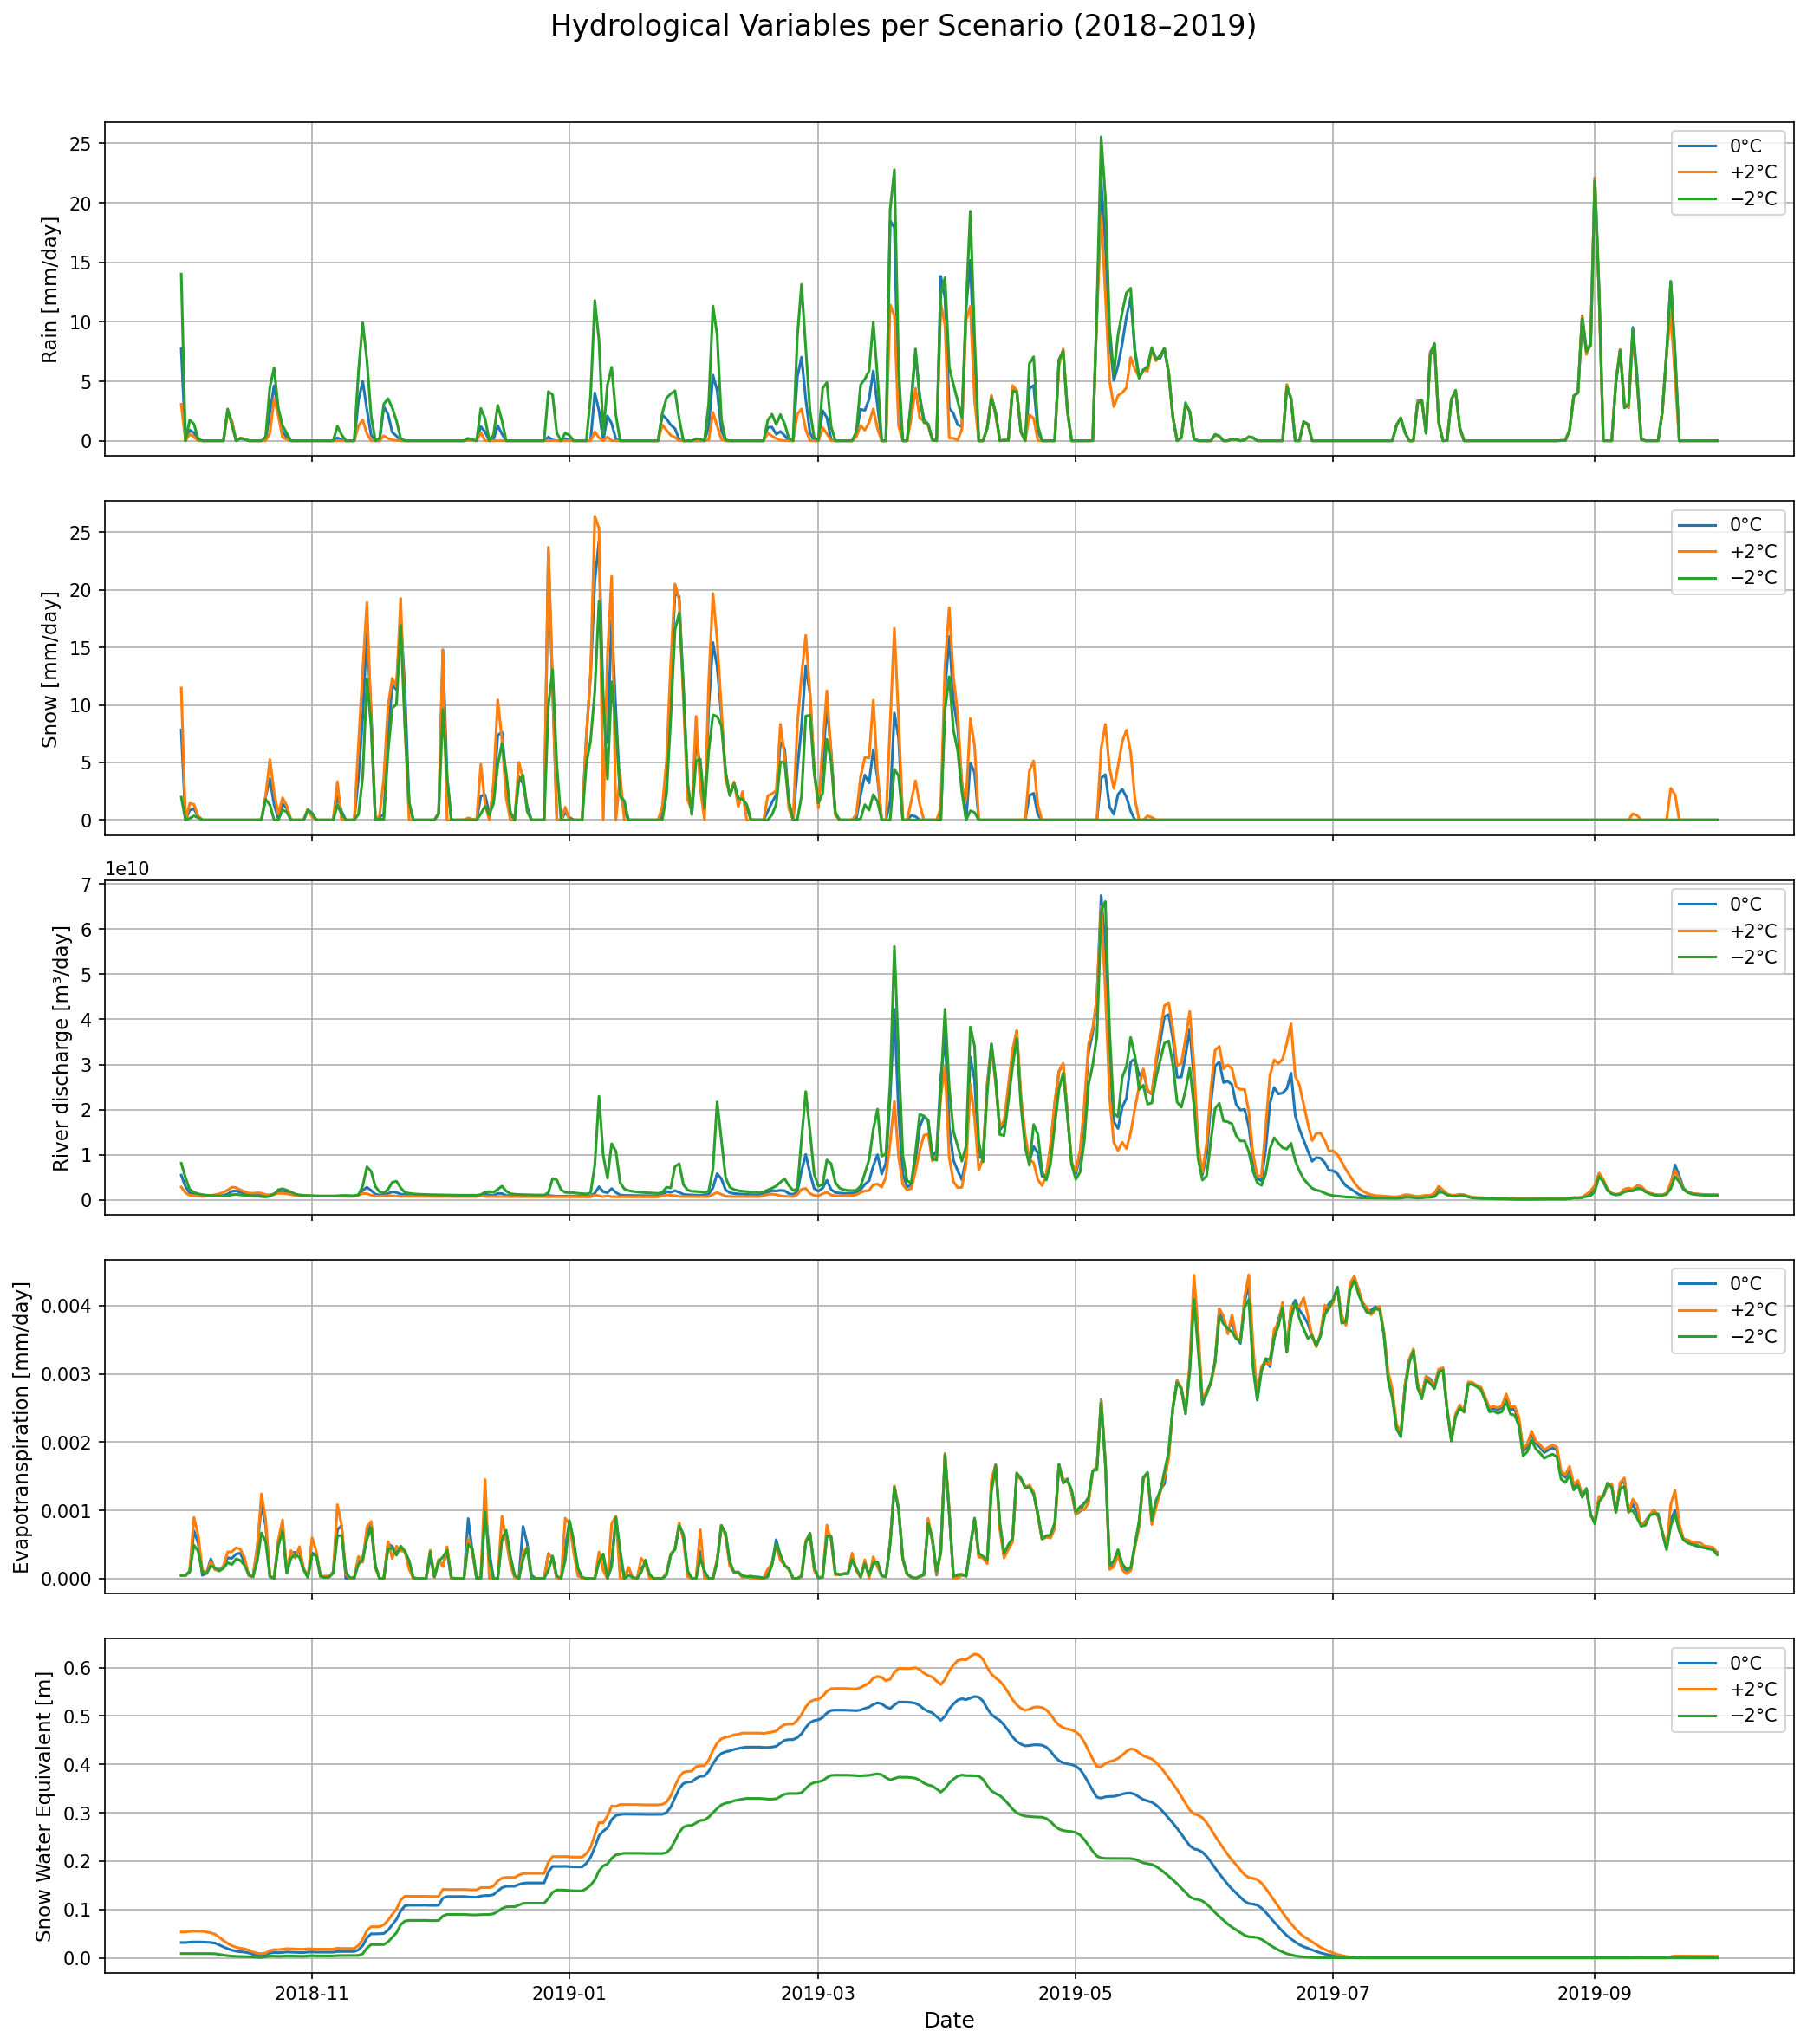

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIGURACIONES ===
work_dir = "../../model2/"  # Ajusta si es necesario
scenarios = {
    "0°C": "3-transient",
    "+2°C": "3-transient-Pos",
    "−2°C": "3-transient-Neg"
}

rho_m = 55500  # mol/m³, densidad molar del agua
# Año hidrológico 2018–2019
start_date = pd.Timestamp("2018-10-01")
end_date = pd.Timestamp("2019-09-30")

variables = {
    "rain precipitation [m d^-1]": "Rain [mm/day]",
    "snow precipitation [m d^-1]": "Snow [mm/day]",
    "total evapotranspiration [m d^-1]": "Evapotranspiration [mm/day]",
    "snow water equivalent [m]": "Snow Water Equivalent [m]",
    "net runoff [mol d^-1]": "River discharge [m³/day]"
}

data_all = {}

# === LECTURA DE DATOS ===
for label, folder in scenarios.items():
    path = os.path.join(work_dir, folder, "water_balance_computational_domain.csv")
    df = pd.read_csv(path, comment="#")
    first_day = df["time [d]"].iloc[0]
    df["date"] = pd.to_datetime("2016-10-01") + pd.to_timedelta(df["time [d]"] - first_day, unit="D")
    df.set_index("date", inplace=True)

    df["Runoff [m³/day]"] = df["net runoff [mol d^-1]"] / rho_m
    df["rain precipitation [m d^-1]"] *= 1000
    df["snow precipitation [m d^-1]"] *= 1000

    df = df[[*variables.keys()]].copy()
    df.rename(columns=variables, inplace=True)
    data_all[label] = df

# === GRAFICOS PARA EL AÑO HIDROLÓGICO 2018–2019 ===
plot_vars = ["Rain [mm/day]", "Snow [mm/day]", "River discharge [m³/day]", "Evapotranspiration [mm/day]", "Snow Water Equivalent [m]"]

fig, axs = plt.subplots(len(plot_vars), 1, figsize=(14, 16), sharex=True)

for i, var in enumerate(plot_vars):
    for label in scenarios:
        subset = data_all[label].loc[start_date:end_date]
        axs[i].plot(subset.index, subset[var], label=label)
    axs[i].set_ylabel(var, fontsize=11)
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel("Date", fontsize=12)
fig.suptitle("Hydrological Variables per Scenario (2018–2019)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()